# OOD Detection for Hardware Verification Properties
**Using Deep Representation Learning**

EEL 6812 — Spring 2026


## Cell 1: Install Dependencies & Setup

In [1]:
# Install sv2v
import os, subprocess, urllib.request, zipfile, shutil

SV2V_VERSION = "v0.0.12"
SV2V_URL = f"https://github.com/zachjs/sv2v/releases/download/{SV2V_VERSION}/sv2v-Linux.zip"

if shutil.which("sv2v") is None:
    print("Installing sv2v...")
    urllib.request.urlretrieve(SV2V_URL, "/tmp/sv2v.zip")
    with zipfile.ZipFile("/tmp/sv2v.zip", 'r') as z:
        z.extractall("/tmp/sv2v_extracted")
    # Find the binary
    for root, dirs, files in os.walk("/tmp/sv2v_extracted"):
        if "sv2v" in files:
            sv2v_path = os.path.join(root, "sv2v")
            os.chmod(sv2v_path, 0o755)
            shutil.copy(sv2v_path, "/usr/local/bin/sv2v")
            break
    print("sv2v installed:", shutil.which("sv2v"))
else:
    print("sv2v already available")

!sv2v --version

# Python dependencies (torch, sklearn, numpy already in Colab)
!pip install -q pyyaml

# Install pyverilog and its dependency (Icarus Verilog)
!apt-get install -y -qq iverilog > /dev/null 2>&1
!pip install -q pyverilog
print("pyverilog installed:", end=" ")
try:
    import pyverilog
    print("OK")
except ImportError:
    print("FAILED")

# Create data directories
os.makedirs("data/rtl", exist_ok=True)
os.makedirs("data/sva", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)

print("\nSetup complete.")

Installing sv2v...
sv2v installed: /usr/local/bin/sv2v
sv2v v0.0.12
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.4/136.4 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.1 MB/s eta 0:00:00
pyverilog installed: OK

Setup complete.


## Cell 2: Upload Your Files

Upload your `.sv` RTL files and `_props.sv` property files.
Filenames must match: e.g. `fifo.sv` (RTL) and `fifo_props.sv` (properties).

In [ ]:
from google.colab import files
import shutil

print("Upload your .sv RTL files and _props.sv property files.")
print("Filenames must match: e.g. fifo.sv + fifo_props.sv\n")

uploaded = files.upload()

for name, content in uploaded.items():
    if name.endswith('_props.sv'):
        dest = f"data/sva/{name}"
    elif name.endswith('.sv') or name.endswith('.v'):
        dest = f"data/rtl/{name}"
    else:
        print(f"  Skipping {name} (not .sv, .v, or _props.sv)")
        continue
    with open(dest, 'wb') as f:
        f.write(content)
    print(f"  {name} -> {dest}")

print(f"\nRTL files: {os.listdir('data/rtl')}")
print(f"SVA files: {os.listdir('data/sva')}")

Upload your .sv RTL files and _props.sv property files.
Filenames must match: e.g. fifo.sv + fifo_props.sv



Saving watchdog_timer_props.sv to watchdog_timer_props.sv
Saving updown_counter_props.sv to updown_counter_props.sv
Saving pulse_stretcher_props.sv to pulse_stretcher_props.sv
Saving priority_encoder_props.sv to priority_encoder_props.sv
Saving popcount_props.sv to popcount_props.sv
Saving parity_unit_props.sv to parity_unit_props.sv
Saving mux_tree_props.sv to mux_tree_props.sv
Saving edge_detector_props.sv to edge_detector_props.sv
Saving dual_port_ram_props.sv to dual_port_ram_props.sv
Saving crc_generator_props.sv to crc_generator_props.sv
Saving comparator_props.sv to comparator_props.sv
Saving clock_divider_props.sv to clock_divider_props.sv
Saving barrel_shifter_props.sv to barrel_shifter_props.sv
Saving skid_buffer_props.sv to skid_buffer_props.sv
Saving shift_register_props.sv to shift_register_props.sv
Saving rr_arbiter_props.sv to rr_arbiter_props.sv
Saving reg_file_props.sv to reg_file_props.sv
Saving lzc_props.sv to lzc_props.sv
Saving handshake_ctrl_props.sv to handshake_

## Cell 3: sv2v Conversion
Convert `.sv` files to `.v` for parsing.

In [3]:
import subprocess
import tempfile
from pathlib import Path

def sv2v_convert(sv_path, out_path, include_dirs=None, defines=None):
    """Convert a single .sv file to .v using sv2v."""
    cmd = ["sv2v"]
    for inc in (include_dirs or []):
        cmd += ["-I", inc]
    for d in (defines or []):
        cmd += ["-D", d]
    cmd.append(str(sv_path))

    res = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    if res.returncode != 0:
        print(f"  ERROR converting {sv_path}: {res.stderr.strip()}")
        return False
    Path(out_path).write_text(res.stdout, encoding="utf-8")
    return True

# Convert all .sv files
rtl_dir = Path("data/rtl")
sv_files = sorted(rtl_dir.glob("*.sv"))

if sv_files:
    print(f"Converting {len(sv_files)} .sv files...")
    for sv_path in sv_files:
        out_path = rtl_dir / f"{sv_path.stem}.v"
        if sv2v_convert(sv_path, out_path):
            print(f"  {sv_path.name} -> {out_path.name}")
else:
    print("No .sv files found (using .v files directly)")

v_files = sorted(rtl_dir.glob("*.v"))
print(f"\nVerilog files ready: {[f.name for f in v_files]}")

Converting 22 .sv files...
  barrel_shifter.sv -> barrel_shifter.v
  clock_divider.sv -> clock_divider.v
  comparator.sv -> comparator.v
  crc_generator.sv -> crc_generator.v
  dual_port_ram.sv -> dual_port_ram.v
  edge_detector.sv -> edge_detector.v
  fifo.sv -> fifo.v
  fixed_latency_pipeline.sv -> fixed_latency_pipeline.v
  fsm_controller.sv -> fsm_controller.v
  handshake_ctrl.sv -> handshake_ctrl.v
  lzc.sv -> lzc.v
  mux_tree.sv -> mux_tree.v
  parity_unit.sv -> parity_unit.v
  popcount.sv -> popcount.v
  priority_encoder.sv -> priority_encoder.v
  pulse_stretcher.sv -> pulse_stretcher.v
  reg_file.sv -> reg_file.v
  rr_arbiter.sv -> rr_arbiter.v
  shift_register.sv -> shift_register.v
  skid_buffer.sv -> skid_buffer.v
  updown_counter.sv -> updown_counter.v
  watchdog_timer.sv -> watchdog_timer.v

Verilog files ready: ['barrel_shifter.v', 'clock_divider.v', 'comparator.v', 'crc_generator.v', 'dual_port_ram.v', 'edge_detector.v', 'fifo.v', 'fixed_latency_pipeline.v', 'fsm_control

## Cell 4: AST Feature Extraction

In [4]:
import re
from pathlib import Path
from dataclasses import dataclass, asdict
import numpy as np
from sklearn.preprocessing import StandardScaler


@dataclass
class RTLFeatures:
    module_name: str
    num_inputs: int = 0
    num_outputs: int = 0
    num_regs: int = 0
    num_wires: int = 0
    num_always_seq: int = 0
    num_always_comb: int = 0
    num_if_stmts: int = 0
    num_case_stmts: int = 0
    num_assignments: int = 0
    num_arith_ops: int = 0
    num_parameters: int = 0
    num_localparams: int = 0
    num_generate_blocks: int = 0
    num_functions: int = 0
    total_lines: int = 0
    has_clock: bool = False

    def to_vector(self) -> np.ndarray:
        total_ports = self.num_inputs + self.num_outputs + 1e-6
        total_always = self.num_always_seq + self.num_always_comb + 1e-6
        total_decl = self.num_regs + self.num_wires + 1e-6
        return np.array([
            self.num_inputs, self.num_outputs,
            self.num_regs, self.num_wires,
            self.num_always_seq, self.num_always_comb,
            self.num_if_stmts + self.num_case_stmts,
            self.num_assignments + self.num_arith_ops,
            self.num_inputs / total_ports,
            self.num_always_seq / total_always,
            self.num_regs / total_decl,
            self.num_parameters + self.num_localparams,
            self.num_generate_blocks,
            self.num_functions,
            self.num_case_stmts,
            float(self.has_clock),
            self.total_lines,
            self.num_if_stmts / (self.total_lines + 1e-6),
        ], dtype=np.float32)

    def to_dict(self) -> dict:
        return asdict(self)


def extract_features_regex(filepath):
    """Regex-based structural feature extraction from a Verilog file."""
    text = Path(filepath).read_text()
    text_nc = re.sub(r'//.*', '', text)
    text_nc = re.sub(r'/\*.*?\*/', '', text_nc, flags=re.DOTALL)

    m = re.search(r'module\s+(\w+)', text_nc)
    module_name = m.group(1) if m else Path(filepath).stem
    feats = RTLFeatures(module_name=module_name)

    feats.total_lines = len(text.strip().split('\n'))
    feats.num_inputs = len(re.findall(r'\binput\b', text_nc))
    feats.num_outputs = len(re.findall(r'\boutput\b', text_nc))
    feats.num_regs = len(re.findall(r'\breg\b', text_nc))
    feats.num_wires = len(re.findall(r'\bwire\b', text_nc))

    always_blocks = re.findall(r'always\s*@\s*\(([^)]*)\)', text_nc)
    for sens in always_blocks:
        if 'posedge' in sens or 'negedge' in sens:
            feats.num_always_seq += 1
        else:
            feats.num_always_comb += 1
    feats.num_always_comb += len(re.findall(r'\balways_comb\b', text_nc))
    feats.num_always_seq += len(re.findall(r'\balways_ff\b', text_nc))

    feats.num_if_stmts = len(re.findall(r'\bif\s*\(', text_nc))
    feats.num_case_stmts = len(re.findall(r'\bcase[xz]?\s*\(', text_nc))
    feats.num_assignments = (
        len(re.findall(r'\bassign\b', text_nc)) +
        len(re.findall(r'<=', text_nc)) +
        len(re.findall(r'(?<![<>!=])=(?!=)', text_nc))
    )
    feats.num_arith_ops = len(re.findall(r'[\+\-\*/%]', text_nc))
    feats.num_parameters = len(re.findall(r'\bparameter\b', text_nc))
    feats.num_localparams = len(re.findall(r'\blocalparam\b', text_nc))
    feats.num_generate_blocks = len(re.findall(r'\bgenerate\b|\bgenvar\b', text_nc))
    feats.num_functions = len(re.findall(r'\bfunction\b', text_nc))
    feats.has_clock = bool(re.search(r'\bclk\b|\bclock\b', text_nc))

    return feats


def try_pyverilog_extract(filepath):
    """Attempt feature extraction using pyverilog's AST."""
    try:
        from pyverilog.vparser.parser import parse
        from pyverilog.vparser import ast as vast
    except ImportError:
        return None

    try:
        ast_tree, _ = parse([str(filepath)])
    except Exception:
        return None

    try:
        description = ast_tree.children()[0]
        if not description.definitions:
            return None
        module_def = description.definitions[0]
    except Exception:
        return None

    feats = RTLFeatures(module_name=module_def.name)
    feats.total_lines = len(Path(filepath).read_text().strip().split('\n'))

    def visit(node):
        if isinstance(node, vast.Input):
            feats.num_inputs += 1
        elif isinstance(node, vast.Output):
            feats.num_outputs += 1
        elif isinstance(node, vast.Reg):
            feats.num_regs += 1
        elif isinstance(node, vast.Wire):
            feats.num_wires += 1
        elif isinstance(node, vast.Always):
            sens = node.sens_list
            if sens:
                sens_str = str(sens)
                if 'posedge' in sens_str or 'negedge' in sens_str:
                    feats.num_always_seq += 1
                else:
                    feats.num_always_comb += 1
        elif isinstance(node, vast.IfStatement):
            feats.num_if_stmts += 1
        elif isinstance(node, vast.CaseStatement):
            feats.num_case_stmts += 1
        elif isinstance(node, vast.Assign) or isinstance(node, vast.NonblockingSubstitution):
            feats.num_assignments += 1
        elif isinstance(node, (vast.Plus, vast.Minus, vast.Times, vast.Divide, vast.Mod)):
            feats.num_arith_ops += 1

        for child in node.children():
            if child is not None:
                visit(child)

    try:
        visit(module_def)
    except Exception:
        return None

    # Supplement with regex for features pyverilog doesn't directly provide
    text = Path(filepath).read_text()
    text_nc = re.sub(r'//.*', '', text)
    text_nc = re.sub(r'/\*.*?\*/', '', text_nc, flags=re.DOTALL)
    feats.num_parameters = len(re.findall(r'\bparameter\b', text_nc))
    feats.num_localparams = len(re.findall(r'\blocalparam\b', text_nc))
    feats.num_generate_blocks = len(re.findall(r'\bgenerate\b|\bgenvar\b', text_nc))
    feats.num_functions = len(re.findall(r'\bfunction\b', text_nc))
    feats.has_clock = bool(re.search(r'\bclk\b|\bclock\b', text_nc))

    return feats


def extract_features(filepath):
    """Extract features — tries pyverilog AST first, falls back to regex."""
    result = try_pyverilog_extract(filepath)
    if result is not None:
        return result, "pyverilog"
    return extract_features_regex(filepath), "regex"


# Extract features from all converted .v files
rtl_dir = Path("data/rtl")
rtl_features = {}
extraction_methods = {}

v_files = sorted(rtl_dir.glob("*.v"))
if not v_files:
    v_files = sorted(rtl_dir.glob("*.sv"))

for v_file in v_files:
    feats, method = extract_features(v_file)
    rtl_features[v_file.stem] = feats
    extraction_methods[v_file.stem] = method

# Report which method was used for each module
pyverilog_count = sum(1 for m in extraction_methods.values() if m == "pyverilog")
regex_count = sum(1 for m in extraction_methods.values() if m == "regex")
print(f"\nExtraction methods: {pyverilog_count} via pyverilog, {regex_count} via regex")
for name in sorted(extraction_methods.keys()):
    print(f"  {name:25s}: {extraction_methods[name]}")

# Store RAW feature vectors (for per-fold scaling in training cells)
rtl_raw_feature_vectors = {}
for name, feats in rtl_features.items():
    rtl_raw_feature_vectors[name] = feats.to_vector().astype(np.float32)

# Also create globally-scaled vectors (for visualization & diagnostics)
_global_scaler = StandardScaler()
_sorted_names = sorted(rtl_raw_feature_vectors.keys())
_raw_matrix = np.stack([rtl_raw_feature_vectors[n] for n in _sorted_names])
_scaled_matrix = _global_scaler.fit_transform(_raw_matrix)

rtl_feature_vectors = {}
for idx, name in enumerate(_sorted_names):
    rtl_feature_vectors[name] = _scaled_matrix[idx].astype(np.float32)

RTL_FEATURE_DIM = _scaled_matrix.shape[1]

# Verification
print("\nScaled feature vectors (for visualization/diagnostics):")
for name, vec in rtl_feature_vectors.items():
    norm = np.linalg.norm(vec)
    print(f"  {name:25s}: norm={norm:.2f}, range=[{vec.min():.2f}, {vec.max():.2f}]")

print(f"\n✓ Features ready")
print(f"  rtl_raw_feature_vectors: raw (for per-fold scaling in training)")
print(f"  rtl_feature_vectors: globally scaled (for visualization)")
print(f"  Feature dimension: {RTL_FEATURE_DIM}")
print(f"  Modules: {len(rtl_feature_vectors)}")

Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables
Generating LALR tables



Extraction methods: 19 via pyverilog, 3 via regex
  barrel_shifter           : pyverilog
  clock_divider            : pyverilog
  comparator               : pyverilog
  crc_generator            : pyverilog
  dual_port_ram            : pyverilog
  edge_detector            : pyverilog
  fifo                     : pyverilog
  fixed_latency_pipeline   : pyverilog
  fsm_controller           : regex
  handshake_ctrl           : pyverilog
  lzc                      : regex
  mux_tree                 : pyverilog
  parity_unit              : pyverilog
  popcount                 : pyverilog
  priority_encoder         : regex
  pulse_stretcher          : pyverilog
  reg_file                 : pyverilog
  rr_arbiter               : pyverilog
  shift_register           : pyverilog
  skid_buffer              : pyverilog
  updown_counter           : pyverilog
  watchdog_timer           : pyverilog

Scaled feature vectors (for visualization/diagnostics):
  barrel_shifter           : norm=3.51, range=

## Cell 4b: Dataset Overview & Feature Visualization

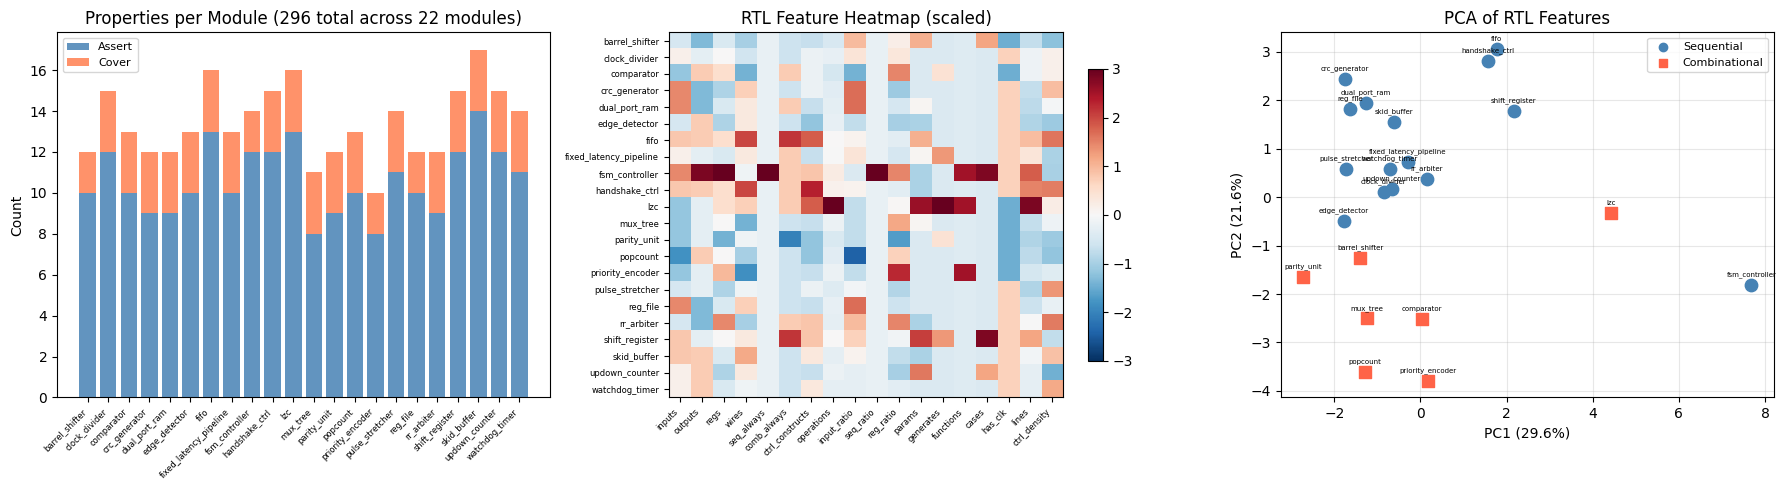

Saved: dataset_overview.png


In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Properties per module
mod_names = sorted(sva_sequences.keys()) if 'sva_sequences' in dir() else sorted(rtl_features.keys())
# Use anonymized_sva if available, else count from sva files
prop_counts = {}
sva_dir = Path("data/sva")
for name in sorted(rtl_features.keys()):
    sva_file = sva_dir / f"{name}_props.sv"
    if sva_file.exists():
        text = sva_file.read_text()
        n_assert = text.count("assert property")
        n_cover = text.count("cover property")
        prop_counts[name] = {"assert": n_assert, "cover": n_cover}

names = list(prop_counts.keys())
n_assert = [prop_counts[n]["assert"] for n in names]
n_cover = [prop_counts[n]["cover"] for n in names]

x = np.arange(len(names))
axes[0].bar(x, n_assert, label="Assert", color="steelblue", alpha=0.85)
axes[0].bar(x, n_cover, bottom=n_assert, label="Cover", color="coral", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=45, ha="right", fontsize=6)
axes[0].set_ylabel("Count")
axes[0].set_title(f"Properties per Module ({sum(n_assert)+sum(n_cover)} total across {len(names)} modules)")
axes[0].legend(fontsize=8)

# Plot 2: Feature heatmap
feat_matrix = np.stack([rtl_feature_vectors[n] for n in names])
feat_labels = ["inputs", "outputs", "regs", "wires", "seq_always", "comb_always",
               "ctrl_constructs", "operations", "input_ratio", "seq_ratio",
               "reg_ratio", "params", "generates", "functions", "cases",
               "has_clk", "lines", "ctrl_density"]
# Truncate labels if needed
feat_labels = feat_labels[:feat_matrix.shape[1]]

im = axes[1].imshow(feat_matrix, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
axes[1].set_xticks(range(len(feat_labels)))
axes[1].set_xticklabels(feat_labels, rotation=45, ha="right", fontsize=6)
axes[1].set_yticks(range(len(names)))
axes[1].set_yticklabels(names, fontsize=6)
axes[1].set_title("RTL Feature Heatmap (scaled)")
plt.colorbar(im, ax=axes[1], shrink=0.8)

# Plot 3: PCA of RTL features
pca = PCA(n_components=2)
projected = pca.fit_transform(feat_matrix)
has_clk = np.array([rtl_features[n].has_clock for n in names])

for i, name in enumerate(names):
    color = "steelblue" if has_clk[i] else "tomato"
    marker = "o" if has_clk[i] else "s"
    axes[2].scatter(projected[i, 0], projected[i, 1], c=color, marker=marker, s=80, zorder=3)
    axes[2].annotate(name, (projected[i, 0], projected[i, 1]),
                     fontsize=5, ha="center", va="bottom", textcoords="offset points",
                     xytext=(0, 5))

axes[2].scatter([], [], c="steelblue", marker="o", label="Sequential")
axes[2].scatter([], [], c="tomato", marker="s", label="Combinational")
axes[2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[2].set_title("PCA of RTL Features")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: dataset_overview.png")

## Cell 5: Identifier Anonymization

In [7]:
import re
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional

VERILOG_KEYWORDS = frozenset([
    "module", "endmodule", "input", "output", "inout", "parameter", "localparam",
    "reg", "wire", "integer", "real", "logic", "bit", "byte",
    "signed", "unsigned",
    "always", "always_comb", "always_ff", "always_latch",
    "initial", "begin", "end", "fork", "join",
    "if", "else", "case", "casex", "casez", "endcase", "default",
    "for", "while", "repeat", "forever", "generate", "endgenerate",
    "assign", "posedge", "negedge", "or", "and", "not", "xor",
    "disable", "iff",
    "assert", "property", "sequence", "endproperty", "endsequence",
    "cover", "assume", "restrict", "expect",
    "throughout", "within", "intersect", "first_match",
    "nexttime", "s_nexttime", "s_always",
    "eventually", "s_eventually", "until", "s_until",
    "until_with", "s_until_with", "implies",
    "rose", "fell", "stable", "changed", "past",
    "onehot", "onehot0", "isunknown", "countones",
    "true", "false",
    "clk", "clock", "rst", "reset",
])

def strip_verilog_comments(text: str) -> str:
    """Remove // line comments and /* ... */ block comments."""
    text = re.sub(r'//.*', '', text)
    text = re.sub(r'/\*.*?\*/', '', text, flags=re.DOTALL)
    return text


def strip_sva_action_blocks(text: str) -> str:
    """
    Remove trailing assertion action blocks like:
      ... ) else $error("msg");
      ... ) else begin ... end
    while preserving the property itself.

    This is a lightweight cleanup, not a full parser.
    """
    # Common case: else $error(...);
    text = re.sub(
        r'\)\s*else\s+\$error\s*\(.*?\)\s*;',
        ');',
        text,
        flags=re.DOTALL
    )

    # Also handle other single-statement else actions conservatively
    # Example: ") else foo = 1;"
    text = re.sub(
        r'\)\s*else\s+[^;]+;',
        ');',
        text,
        flags=re.DOTALL
    )

    return text


def normalize_whitespace(text: str) -> str:
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


@dataclass
class AnonymizationMap:
    input_counter: int = 0
    output_counter: int = 0
    generic_counter: int = 0
    mapping: dict = field(default_factory=dict)
    reverse_mapping: dict = field(default_factory=dict)

    def get_or_assign(self, identifier, role=None):
        if identifier in self.mapping:
            return self.mapping[identifier]
        if role == "input":
            token = f"IN_{self.input_counter}"
            self.input_counter += 1
        elif role == "output":
            token = f"OUT_{self.output_counter}"
            self.output_counter += 1
        else:
            token = f"ID_{self.generic_counter}"
            self.generic_counter += 1
        self.mapping[identifier] = token
        self.reverse_mapping[token] = identifier
        return token


def _extract_port_roles(rtl_text):
    rtl_text = strip_verilog_comments(rtl_text)
    roles = {}
    for match in re.finditer(
        r'\b(input|output)\s+(?:wire|reg|logic)?\s*(?:signed|unsigned)?\s*'
        r'(?:\[[^\]]*\]\s*)?(\w+(?:\s*,\s*\w+)*)',
        rtl_text
    ):
        direction = match.group(1)
        names = [n.strip() for n in match.group(2).split(',')]
        for name in names:
            if name and name.lower() not in VERILOG_KEYWORDS:
                roles[name] = direction
    return roles


def anonymize_rtl(rtl_text, preserve_port_roles=True, anon_map=None):
    if anon_map is None:
        anon_map = AnonymizationMap()

    rtl_text = strip_verilog_comments(rtl_text)
    port_roles = _extract_port_roles(rtl_text) if preserve_port_roles else {}
    identifier_pattern = re.compile(r'\b([a-zA-Z_]\w*)\b')

    def replacer(match):
        ident = match.group(1)
        if ident.lower() in VERILOG_KEYWORDS:
            return ident
        if ident.startswith('$'):
            return ident
        role = port_roles.get(ident)
        return anon_map.get_or_assign(ident, role=role)

    anonymized = identifier_pattern.sub(replacer, rtl_text)
    return anonymized, anon_map


def anonymize_sva(sva_text, anon_map):
    identifier_pattern = re.compile(r'\b([a-zA-Z_]\w*)\b')

    def replacer(match):
        ident = match.group(1)
        if ident.lower() in VERILOG_KEYWORDS:
            return ident
        return anon_map.get_or_assign(ident, role=None)

    return identifier_pattern.sub(replacer, sva_text)


def parse_sva_file(filepath):
    """Parse an SVA file into individual property strings."""
    text = Path(filepath).read_text()

    # Clean raw text first
    text = strip_verilog_comments(text)
    text = strip_sva_action_blocks(text)
    text = normalize_whitespace(text)

    # Split on assert/assume/cover property, keeping the keyword in each chunk
    props = re.split(r'(?=\b(?:assert|assume|cover)\s+property\b)', text)
    props = [p.strip().rstrip(';').strip() for p in props if p.strip()]

    # Fallback if the main split found nothing
    if not props:
        props = [p.strip() for p in text.split(';') if p.strip()]

    # Merge orphaned labels back into their assertion
    merged = []
    pending_label = None

    for p in props:
        has_property = re.search(r'\b(assert|assume|cover)\s+property\b', p) is not None

        if not has_property:
            if pending_label is None:
                pending_label = p
            else:
                pending_label = pending_label + ' ' + p
        else:
            if pending_label is not None:
                merged.append(normalize_whitespace(pending_label + ' ' + p))
                pending_label = None
            else:
                merged.append(normalize_whitespace(p))

    if pending_label is not None:
        merged.append(normalize_whitespace(pending_label))

    return merged


# Anonymize all modules
ANONYMIZE = True

sva_dir = Path("data/sva")
rtl_dir = Path("data/rtl")

# Discover matching pairs
modules = {}
for v_file in sorted(rtl_dir.glob("*.v")):
    stem = v_file.stem
    sva_file = sva_dir / f"{stem}_props.sv"
    if sva_file.exists():
        modules[stem] = (v_file, sva_file)
    else:
        print(f"  Warning: No SVA file for {stem}")

print(f"Found {len(modules)} module/property pairs: {list(modules.keys())}\n")

# Process each module
anonymized_sva = {}  # {module_name: [list of property strings]}
anon_maps = {}       # {module_name: AnonymizationMap}

for name, (rtl_path, sva_path) in modules.items():
    raw_props = parse_sva_file(sva_path)

    if ANONYMIZE:
        anon_map = AnonymizationMap()
        rtl_text = rtl_path.read_text()
        _, anon_map = anonymize_rtl(rtl_text, preserve_port_roles=True, anon_map=anon_map)
        anon_props = [anonymize_sva(prop, anon_map) for prop in raw_props]
        anonymized_sva[name] = anon_props
        anon_maps[name] = anon_map

        print(f"{name}: {len(anon_props)} properties (anonymized, {len(anon_map.mapping)} identifiers)")
        if raw_props:
            print(f"  Original:   {raw_props[0][:120]}...")
            print(f"  Anonymized: {anon_props[0][:120]}...")
    else:
        anonymized_sva[name] = raw_props
        print(f"{name}: {len(raw_props)} properties (original identifiers)")
        if raw_props:
            print(f"  Original:   {raw_props[0][:120]}...")

Found 22 module/property pairs: ['barrel_shifter', 'clock_divider', 'comparator', 'crc_generator', 'dual_port_ram', 'edge_detector', 'fifo', 'fixed_latency_pipeline', 'fsm_controller', 'handshake_ctrl', 'lzc', 'mux_tree', 'parity_unit', 'popcount', 'priority_encoder', 'pulse_stretcher', 'reg_file', 'rr_arbiter', 'shift_register', 'skid_buffer', 'updown_counter', 'watchdog_timer']

barrel_shifter: 12 properties (anonymized, 30 identifiers)
  Original:   ast_sll_zero: assert property ( (mode_i == 2'b00 && shamt_i == '0) |-> result_o == data_i ); ast_srl_zero:...
  Anonymized: ID_11: assert property ( (IN_2 == 2'ID_6 && IN_1 == '0) |-> OUT_0 == IN_0 ); ID_12:...
clock_divider: 15 properties (anonymized, 26 identifiers)
  Original:   ast_reset_clk_low: assert property ( @(posedge clk) reset |=> clk_out == 1'b0 ); ast_reset_counter:...
  Anonymized: ID_7: assert property ( @(posedge clk) reset |=> OUT_0 == 1'ID_5 ); ID_8:...
comparator: 13 properties (anonymized, 25 identifiers)
  Original:

## Cell 6: SVA Tokenizer

In [8]:
import json

SVA_SPECIAL_TOKENS = [
    "|->", "|=>",
    "##",
    "[*", "[=", "[->",
    "<=", ">=", "!=", "==", "===", "!==",
    "&&", "||",
    ">>", "<<",
]

class SVATokenizer:
    PAD = "<PAD>"
    UNK = "<UNK>"
    BOS = "<BOS>"
    EOS = "<EOS>"

    def __init__(self, max_seq_len=128):
        self.max_seq_len = max_seq_len
        self.token2idx = {}
        self.idx2token = {}
        for i, tok in enumerate([self.PAD, self.UNK, self.BOS, self.EOS]):
            self.token2idx[tok] = i
            self.idx2token[i] = tok

    @property
    def vocab_size(self):
        return len(self.token2idx)

    @property
    def pad_idx(self):
        return self.token2idx[self.PAD]

    def tokenize(self, text):
        tokens = []
        i = 0
        while i < len(text):
            if text[i].isspace():
                i += 1
                continue
            matched = False
            for op in sorted(SVA_SPECIAL_TOKENS, key=len, reverse=True):
                if text[i:i+len(op)] == op:
                    tokens.append(op)
                    i += len(op)
                    matched = True
                    break
            if matched:
                continue
            if text[i].isalpha() or text[i] == '_':
                j = i + 1
                while j < len(text) and (text[j].isalnum() or text[j] == '_'):
                    j += 1
                tokens.append(text[i:j])
                i = j
                continue
            if text[i].isdigit():
                j = i + 1
                while j < len(text) and (text[j].isalnum() or text[j] in "'_"):
                    j += 1
                tokens.append(text[i:j])
                i = j
                continue
            tokens.append(text[i])
            i += 1
        return tokens

    def build_vocab(self, texts):
        all_tokens = set()
        for text in texts:
            all_tokens.update(self.tokenize(text))
        idx = len(self.token2idx)
        for token in sorted(all_tokens):
            if token not in self.token2idx:
                self.token2idx[token] = idx
                self.idx2token[idx] = token
                idx += 1

    def encode(self, text):
        tokens = self.tokenize(text)
        tokens = tokens[:self.max_seq_len - 2]
        ids = [self.token2idx[self.BOS]]
        for tok in tokens:
            ids.append(self.token2idx.get(tok, self.token2idx[self.UNK]))
        ids.append(self.token2idx[self.EOS])
        while len(ids) < self.max_seq_len:
            ids.append(self.pad_idx)
        return ids

    def decode(self, ids):
        tokens = []
        for idx in ids:
            tok = self.idx2token.get(idx, self.UNK)
            if tok in (self.PAD, self.BOS, self.EOS):
                continue
            tokens.append(tok)
        return " ".join(tokens)


# Build vocabulary and encode all properties
MAX_SEQ_LEN = 128

all_prop_texts = []
for props in anonymized_sva.values():
    all_prop_texts.extend(props)

tokenizer = SVATokenizer(max_seq_len=MAX_SEQ_LEN)
tokenizer.build_vocab(all_prop_texts)
print(f"Vocabulary size: {tokenizer.vocab_size}")

# Encode
sva_sequences = {}
sva_lengths = {}
for name, props in anonymized_sva.items():
    seqs, lens = [], []
    for prop in props:
        tokens = tokenizer.tokenize(prop)
        encoded = tokenizer.encode(prop)
        seqs.append(encoded)
        lens.append(min(len(tokens) + 2, MAX_SEQ_LEN))
    sva_sequences[name] = seqs
    sva_lengths[name] = lens
    print(f"  {name}: {len(seqs)} properties, token lengths: {lens}")

print(f"\nReady: {len(rtl_feature_vectors)} modules, {sum(len(v) for v in sva_sequences.values())} total properties")

Vocabulary size: 146
  barrel_shifter: 12 properties, token lengths: [25, 23, 23, 24, 24, 26, 26, 27, 32, 16, 21, 22]
  clock_divider: 15 properties, token lengths: [21, 20, 18, 36, 31, 35, 34, 28, 29, 29, 24, 22, 26, 20, 24]
  comparator: 13 properties, token lengths: [20, 14, 14, 13, 13, 15, 22, 13, 22, 20, 10, 10, 7]
  crc_generator: 12 properties, token lengths: [22, 28, 34, 59, 56, 24, 24, 32, 39, 31, 23, 23]
  dual_port_ram: 12 properties, token lengths: [32, 37, 24, 26, 26, 24, 38, 32, 34, 21, 20, 25]
  edge_detector: 13 properties, token lengths: [22, 27, 27, 26, 22, 21, 27, 26, 20, 33, 23, 23, 25]
  fifo: 16 properties, token lengths: [27, 22, 27, 30, 30, 27, 31, 27, 24, 24, 42, 39, 39, 20, 27, 25]
  fixed_latency_pipeline: 13 properties, token lengths: [23, 24, 22, 24, 26, 34, 35, 28, 27, 36, 23, 23, 20]
  fsm_controller: 14 properties, token lengths: [29, 25, 27, 26, 40, 30, 30, 43, 43, 37, 33, 30, 57, 42]
  handshake_ctrl: 15 properties, token lengths: [28, 22, 23, 27, 35, 

## Cell 7: Model Definition (BiLSTM + Joint Classifier + Energy OOD)

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class AttentionPooling(nn.Module):
    """Learned attention pooling over sequence outputs."""
    def __init__(self, input_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(input_dim, input_dim // 2),
            nn.Tanh(),
            nn.Linear(input_dim // 2, 1)
        )

    def forward(self, x, mask=None):
        """
        x:    [B, T, D]
        mask: [B, T] boolean, True for valid tokens
        """
        scores = self.attn(x).squeeze(-1)   # [B, T]

        if mask is not None:
            scores = scores.masked_fill(~mask, float("-inf"))

        weights = torch.softmax(scores, dim=1)   # [B, T]
        pooled = torch.sum(x * weights.unsqueeze(-1), dim=1)   # [B, D]
        return pooled, weights

class BiLSTMEncoderV2(nn.Module):
    """BiLSTM with mean + max + attention pooling."""
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=96,
                 num_layers=1, dropout=0.2, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.attn_pool = AttentionPooling(hidden_dim * 2)

        # mean (2H) + max (2H) + attn (2H) -> 6H, then project
        self.proj = nn.Linear(hidden_dim * 6, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    @property
    def output_dim(self):
        return self.proj.out_features

    def forward(self, input_ids, lengths=None, return_attention=False):
        x = self.dropout(self.embedding(input_ids))

        if lengths is not None:
            lengths_cpu = lengths.cpu().clamp(min=1)
            packed = pack_padded_sequence(x, lengths_cpu, batch_first=True, enforce_sorted=False)
            packed_out, _ = self.lstm(packed)
            out, _ = pad_packed_sequence(packed_out, batch_first=True)
        else:
            out, _ = self.lstm(x)
            lengths = torch.full((x.size(0),), x.size(1), device=x.device, dtype=torch.long)

        # Build mask for valid positions
        max_len = out.size(1)
        mask = torch.arange(max_len, device=out.device)[None, :] < lengths[:, None]
        mask_f = mask.unsqueeze(-1).float()

        # Mean pooling (masked)
        mean_pool = (out * mask_f).sum(dim=1) / mask_f.sum(dim=1).clamp(min=1.0)

        # Max pooling (masked)
        out_masked = out.masked_fill(~mask.unsqueeze(-1), float("-inf"))
        max_pool = out_masked.max(dim=1).values
        max_pool[max_pool == float("-inf")] = 0.0

        # Attention pooling
        attn_pool, attn_weights = self.attn_pool(out, mask=mask)

        pooled = torch.cat([mean_pool, max_pool, attn_pool], dim=1)
        pooled = self.dropout(pooled)
        pooled = self.proj(pooled)

        if return_attention:
            return pooled, attn_weights
        return pooled


class RTLFeatureEncoderV2(nn.Module):
    """RTL feature encoder with LayerNorm and GELU."""
    def __init__(self, input_dim=18, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
        )

    def forward(self, features):
        return self.net(features)


class CompatibilityClassifier(nn.Module):
    """
    V2 Joint classifier with:
    - Projected RTL and SVA embeddings to shared match_dim
    - Richer fusion: [rtl, sva, |rtl-sva|, rtl*sva]
    - LayerNorm before classifier
    """
    def __init__(self, vocab_size, rtl_feature_dim=18, rtl_hidden_dim=64,
                 embedding_dim=64, lstm_hidden_dim=96, lstm_num_layers=1,
                 lstm_dropout=0.2, joint_hidden_dim=128, num_classes=2, pad_idx=0):
        super().__init__()

        self.rtl_encoder = RTLFeatureEncoderV2(rtl_feature_dim, rtl_hidden_dim, dropout=0.2)
        self.sva_encoder = BiLSTMEncoderV2(
            vocab_size=vocab_size,
            embedding_dim=embedding_dim,
            hidden_dim=lstm_hidden_dim,
            num_layers=lstm_num_layers,
            dropout=lstm_dropout,
            pad_idx=pad_idx,
        )

        match_dim = 64
        self.rtl_proj = nn.Linear(rtl_hidden_dim, match_dim)
        self.sva_proj = nn.Linear(self.sva_encoder.output_dim, match_dim)

        # 4 * match_dim: [rtl, sva, |rtl-sva|, rtl*sva]
        self.classifier = nn.Sequential(
            nn.LayerNorm(match_dim * 4),
            nn.Linear(match_dim * 4, joint_hidden_dim),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(joint_hidden_dim, joint_hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(joint_hidden_dim // 2, num_classes),
        )
        self.num_classes = num_classes

    def encode_pair(self, rtl_features, sva_input_ids, sva_lengths=None):
        """Return L2-normalized projected RTL and SVA embeddings."""
        rtl = self.rtl_proj(self.rtl_encoder(rtl_features))
        sva = self.sva_proj(self.sva_encoder(sva_input_ids, sva_lengths))
        rtl = F.normalize(rtl, dim=1)
        sva = F.normalize(sva, dim=1)
        return rtl, sva

    def forward(self, rtl_features, sva_input_ids, sva_lengths=None):
        rtl, sva = self.encode_pair(rtl_features, sva_input_ids, sva_lengths)
        feat = torch.cat([rtl, sva, torch.abs(rtl - sva), rtl * sva], dim=1)
        return self.classifier(feat)

    def get_embeddings(self, rtl_features, sva_input_ids, sva_lengths=None):
        return self.encode_pair(rtl_features, sva_input_ids, sva_lengths)


def energy_score(logits, temperature=1.0):
    """Raw energy: E(x) = -T * logsumexp(logits / T).
    With this convention, higher energy = more OOD-like, so it can be
    passed directly to metrics that expect higher = more OOD.
    """
    return -temperature * torch.logsumexp(logits / temperature, dim=1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

_test_model = CompatibilityClassifier(vocab_size=50, rtl_feature_dim=18)
_test_logits = _test_model(torch.randn(2, 18), torch.randint(0, 50, (2, 20)),
                           torch.tensor([20, 15]))
print(f"Model output shape: {_test_logits.shape}")
_rtl, _sva = _test_model.encode_pair(torch.randn(2, 18), torch.randint(0, 50, (2, 20)),
                                      torch.tensor([20, 15]))
print(f"RTL embedding: {_rtl.shape}, SVA embedding: {_sva.shape}")
print(f"Energy scores: {energy_score(_test_logits)}")
n_params = sum(p.numel() for p in _test_model.parameters())
print(f"Parameters: {n_params:,}")
del _test_model, _test_logits, _rtl, _sva
print("Model V2 definition OK.")

Device: cpu
Model output shape: torch.Size([2, 2])
RTL embedding: torch.Size([2, 64]), SVA embedding: torch.Size([2, 64])
Energy scores: tensor([-0.7668, -0.6676], grad_fn=<MulBackward0>)
Parameters: 259,207
Model V2 definition OK.


## Cell 8: Dataset & DataLoader

In [33]:
import random
from torch.utils.data import Dataset, DataLoader, random_split


class CompatibilityDataset(Dataset):
    def __init__(self, rtl_features, sva_sequences, sva_lengths,
                 include_ood=True, ood_ratio=1.0, seed=42):
        super().__init__()
        self.samples = []
        rng = random.Random(seed)
        module_names = sorted(rtl_features.keys())

        # In-distribution pairs
        for mod in module_names:
            feat = rtl_features[mod]
            for seq, length in zip(sva_sequences[mod], sva_lengths[mod]):
                self.samples.append((feat, seq, length, 1, mod))

        # OOD pairs (cross-apply properties to wrong modules)
        if include_ood and len(module_names) > 1:
            id_count = len(self.samples)
            target_ood = int(id_count * ood_ratio)
            ood_samples = []
            for mod in module_names:
                other_modules = [m for m in module_names if m != mod]
                feat = rtl_features[mod]
                for other_mod in other_modules:
                    for seq, length in zip(sva_sequences[other_mod], sva_lengths[other_mod]):
                        ood_samples.append((feat, seq, length, 0, mod))
            if len(ood_samples) > target_ood:
                rng.shuffle(ood_samples)
                ood_samples = ood_samples[:target_ood]
            self.samples.extend(ood_samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        feat, seq, length, label, mod = self.samples[idx]
        return {
            "rtl_features": torch.tensor(feat, dtype=torch.float32),
            "sva_input_ids": torch.tensor(seq, dtype=torch.long),
            "sva_length": torch.tensor(length, dtype=torch.long),
            "label": torch.tensor(label, dtype=torch.long),
        }

    def get_module_name(self, idx):
        return self.samples[idx][4]


def leave_one_out_split(rtl_features, sva_sequences, sva_lengths,
                        held_out_module, ood_ratio=1.0, seed=42):
    # Training: all modules except held-out, with hard negatives
    train_mods = {k: v for k, v in rtl_features.items() if k != held_out_module}
    train_sva = {k: v for k, v in sva_sequences.items() if k != held_out_module}
    train_len = {k: v for k, v in sva_lengths.items() if k != held_out_module}

    train_ds = HardNegativeDataset(
        train_mods, train_sva, train_len,
        include_ood=True, ood_ratio=ood_ratio, seed=seed,
        hard_negative_ratio=0.5, k_nearest=3,
    )

    # Test: manually build balanced ID + OOD for held-out module
    test_samples = []
    held_feat = rtl_features[held_out_module]

    # ID pairs
    for seq, length in zip(sva_sequences[held_out_module], sva_lengths[held_out_module]):
        test_samples.append((held_feat, seq, length, 1, held_out_module))

    # OOD pairs (also use hard negatives for test)
    rng = random.Random(seed + 1)

    # Find nearest modules to held-out
    distances = []
    for mod in train_mods:
        d = np.linalg.norm(np.array(rtl_features[held_out_module]) - np.array(rtl_features[mod]))
        distances.append((mod, d))
    distances.sort(key=lambda x: x[1])
    nearest_mods = [m for m, _ in distances[:3]]
    other_mods = [m for m, _ in distances[3:]]

    ood_samples = []
    # 50% from nearest neighbors
    for mod in nearest_mods:
        for seq, length in zip(sva_sequences[mod], sva_lengths[mod]):
            ood_samples.append((held_feat, seq, length, 0, held_out_module))
    # 50% from random others
    for mod in other_mods:
        for seq, length in zip(sva_sequences[mod], sva_lengths[mod]):
            ood_samples.append((held_feat, seq, length, 0, held_out_module))

    # Balance OOD to match ID count
    n_id = len(test_samples)
    if len(ood_samples) > n_id:
        rng.shuffle(ood_samples)
        ood_samples = ood_samples[:n_id]
    test_samples.extend(ood_samples)

    test_ds = ManualDataset(test_samples)
    return train_ds, test_ds


class ManualDataset(Dataset):
    """Simple dataset from a pre-built list of samples."""
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        feat, seq, length, label, mod = self.samples[idx]
        return {
            "rtl_features": torch.tensor(feat, dtype=torch.float32),
            "sva_input_ids": torch.tensor(seq, dtype=torch.long),
            "sva_length": torch.tensor(length, dtype=torch.long),
            "label": torch.tensor(label, dtype=torch.long),
        }

    def get_module_name(self, idx):
        return self.samples[idx][4]


class HardNegativeDataset(Dataset):
    """Dataset with hard-negative sampling from structurally similar modules."""
    def __init__(self, rtl_features, sva_sequences, sva_lengths,
                 include_ood=True, ood_ratio=1.0, seed=42,
                 hard_negative_ratio=0.5, k_nearest=3):
        super().__init__()
        self.samples = []
        rng = random.Random(seed)
        module_names = sorted(rtl_features.keys())

        # In-distribution pairs
        for mod in module_names:
            feat = rtl_features[mod]
            for seq, length in zip(sva_sequences[mod], sva_lengths[mod]):
                self.samples.append((feat, seq, length, 1, mod))

        if not include_ood or len(module_names) <= 1:
            return

        # Precompute nearest neighbors for each module
        nearest = {}
        for mod in module_names:
            distances = []
            for other in module_names:
                if other != mod:
                    d = np.linalg.norm(
                        np.array(rtl_features[mod]) - np.array(rtl_features[other])
                    )
                    distances.append((other, d))
            distances.sort(key=lambda x: x[1])
            nearest[mod] = [m for m, _ in distances[:k_nearest]]

        id_count = len(self.samples)
        target_ood = int(id_count * ood_ratio)
        n_hard = int(target_ood * hard_negative_ratio)
        n_random = target_ood - n_hard

        # Hard negatives: from nearest neighbors
        hard_samples = []
        for mod in module_names:
            feat = rtl_features[mod]
            for near_mod in nearest[mod]:
                for seq, length in zip(sva_sequences[near_mod], sva_lengths[near_mod]):
                    hard_samples.append((feat, seq, length, 0, mod))

        if len(hard_samples) > n_hard:
            rng.shuffle(hard_samples)
            hard_samples = hard_samples[:n_hard]

        # Random negatives: from any non-matching module
        random_samples = []
        for mod in module_names:
            feat = rtl_features[mod]
            non_nearest = [m for m in module_names if m != mod and m not in nearest[mod]]
            for other_mod in non_nearest:
                for seq, length in zip(sva_sequences[other_mod], sva_lengths[other_mod]):
                    random_samples.append((feat, seq, length, 0, mod))

        if len(random_samples) > n_random:
            rng.shuffle(random_samples)
            random_samples = random_samples[:n_random]

        self.samples.extend(hard_samples)
        self.samples.extend(random_samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        feat, seq, length, label, mod = self.samples[idx]
        return {
            "rtl_features": torch.tensor(feat, dtype=torch.float32),
            "sva_input_ids": torch.tensor(seq, dtype=torch.long),
            "sva_length": torch.tensor(length, dtype=torch.long),
            "label": torch.tensor(label, dtype=torch.long),
        }

    def get_module_name(self, idx):
        return self.samples[idx][4]

# Constants
SEED = 42
BATCH_SIZE = 16

print(f"Dataset classes defined. SEED={SEED}, BATCH_SIZE={BATCH_SIZE}")
print(f"Available: CompatibilityDataset, HardNegativeDataset, ManualDataset, leave_one_out_split")
print(f"Modules: {len(rtl_feature_vectors)}, Properties: {sum(len(v) for v in sva_sequences.values())}")


Dataset classes defined. SEED=42, BATCH_SIZE=16
Available: CompatibilityDataset, HardNegativeDataset, ManualDataset, leave_one_out_split
Modules: 22, Properties: 296


## Cell 9: Metrics

In [34]:
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, f1_score
from dataclasses import dataclass

@dataclass
class OODMetrics:
    auroc: float
    fpr_at_95tpr: float
    classification_accuracy: float
    f1: float

    def __str__(self):
        return (f"AUROC: {self.auroc:.4f} | FPR@95TPR: {self.fpr_at_95tpr:.4f} | "
                f"Acc: {self.classification_accuracy:.4f} | F1: {self.f1:.4f}")


def compute_auroc(labels, scores):
    """Higher scores = more OOD. No direction flipping."""
    ood_labels = 1 - labels
    if len(np.unique(ood_labels)) < 2:
        return 0.5
    try:
        return roc_auc_score(ood_labels, scores)
    except ValueError:
        return 0.5

def compute_fpr_at_95tpr(labels, scores):
    """Higher scores = more OOD. No direction flipping."""
    ood_labels = 1 - labels
    if len(np.unique(ood_labels)) < 2:
        return 1.0
    try:
        fpr, tpr, _ = roc_curve(ood_labels, scores)
        idx = np.searchsorted(tpr, 0.95)
        return fpr[min(idx, len(fpr) - 1)]
    except ValueError:
        return 1.0

def compute_all_metrics(labels, predictions, energy_scores):
    return OODMetrics(
        auroc=compute_auroc(labels, energy_scores),
        fpr_at_95tpr=compute_fpr_at_95tpr(labels, energy_scores),
        classification_accuracy=accuracy_score(labels, predictions),
        f1=f1_score(labels, predictions, zero_division=0),
    )

# Sanity check
_l = np.array([1,1,1,0,0,0])
_s = np.array([-3,-2,-1,1,2,3])  # higher = more OOD
print(f"Sanity check — perfect separation: AUROC={compute_auroc(_l,_s):.2f} (expect 1.00)")
print(f"Sanity check — FPR@95TPR={compute_fpr_at_95tpr(_l,_s):.2f} (expect 0.00)")
print("Metrics OK.")

Sanity check — perfect separation: AUROC=1.00 (expect 1.00)
Sanity check — FPR@95TPR=0.00 (expect 0.00)
Metrics OK.


## Cell 10: Training w/ LOO

In [ ]:
# === BASE LOO (no energy-bounded learning) ===
# Results saved to base_* variables
import time
import warnings
warnings.filterwarnings('ignore')

# Hyperparameters
RTL_HIDDEN_DIM = 64
EMBEDDING_DIM = 32
LSTM_HIDDEN_DIM = 64
LSTM_NUM_LAYERS = 1
LSTM_DROPOUT = 0.2
JOINT_HIDDEN_DIM = 128
NUM_CLASSES = 2
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-3
EPOCHS = 300
PATIENCE = 30
TEMPERATURE = 1.0
CONTRASTIVE_WEIGHT = 0.05    # weight for cosine embedding loss
CONTRASTIVE_MARGIN = 0.2

module_names = sorted(rtl_feature_vectors.keys())
base_loo_results = {}
base_histories = {}

base_fold_labels = []
base_fold_preds = []
base_fold_energy = []
base_fold_confidence = []

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
contrastive_criterion = nn.CosineEmbeddingLoss(margin=CONTRASTIVE_MARGIN)

print(f"Model V2: BiLSTM({EMBEDDING_DIM},{LSTM_HIDDEN_DIM}) + RTL({RTL_FEATURE_DIM},{RTL_HIDDEN_DIM}) + Joint({JOINT_HIDDEN_DIM})")
print(f"LR={LEARNING_RATE}, WD={WEIGHT_DECAY}, Patience={PATIENCE}")
print(f"Label smoothing=0.05, Contrastive weight={CONTRASTIVE_WEIGHT}, margin={CONTRASTIVE_MARGIN}")
print(f"\nTraining with Leave-One-Out CV across {len(module_names)} modules...")
print("Early stopping uses internal validation split, NOT the test fold.")
print("=" * 90)

from sklearn.preprocessing import StandardScaler

for fold, held_out in enumerate(module_names):
    torch.manual_seed(SEED)

    # Fit scaler on training modules only for this fold
    train_modules_for_scaler = [m for m in module_names if m != held_out]

    scaler = StandardScaler()
    train_matrix = np.stack([rtl_feature_vectors[m] for m in train_modules_for_scaler])
    scaler.fit(train_matrix)

    rtl_feature_vectors_fold = {}
    for m in module_names:
        rtl_feature_vectors_fold[m] = scaler.transform(
            rtl_feature_vectors[m].reshape(1, -1)
        )[0].astype(np.float32)

    train_ds_full, test_ds = leave_one_out_split(
        rtl_feature_vectors_fold, sva_sequences, sva_lengths,
        held_out_module=held_out, ood_ratio=1.0, seed=SEED,
    )

    # Internal validation split for early stopping
    n_val_inner = max(2, int(0.15 * len(train_ds_full)))
    n_train_inner = len(train_ds_full) - n_val_inner
    train_ds, val_ds_inner = random_split(
        train_ds_full, [n_train_inner, n_val_inner],
        generator=torch.Generator().manual_seed(SEED + fold)
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader_inner = DataLoader(val_ds_inner, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    fold_model = CompatibilityClassifier(
        vocab_size=tokenizer.vocab_size,
        rtl_feature_dim=RTL_FEATURE_DIM, rtl_hidden_dim=RTL_HIDDEN_DIM,
        embedding_dim=EMBEDDING_DIM, lstm_hidden_dim=LSTM_HIDDEN_DIM,
        lstm_num_layers=LSTM_NUM_LAYERS, lstm_dropout=LSTM_DROPOUT,
        joint_hidden_dim=JOINT_HIDDEN_DIM, num_classes=NUM_CLASSES,
        pad_idx=tokenizer.pad_idx,
    ).to(device)

    fold_optimizer = torch.optim.AdamW(
        fold_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )

    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None
    fold_history = {"train_loss": [], "test_loss": []}

    for epoch in range(1, EPOCHS + 1):
        # Train
        fold_model.train()
        total_loss, n_batches = 0.0, 0
        for batch in train_loader:
            rtl_feat = batch["rtl_features"].to(device)
            sva_ids = batch["sva_input_ids"].to(device)
            sva_len = batch["sva_length"].to(device)
            labels = batch["label"].to(device)

            fold_optimizer.zero_grad()

            # Classification loss
            logits = fold_model(rtl_feat, sva_ids, sva_len)
            ce_loss = criterion(logits, labels)

            # Contrastive loss on embeddings
            rtl_emb, sva_emb = fold_model.encode_pair(rtl_feat, sva_ids, sva_len)
            # CosineEmbeddingLoss expects target: +1 for matched, -1 for mismatched
            contrastive_target = labels.float() * 2 - 1
            metric_loss = contrastive_criterion(rtl_emb, sva_emb, contrastive_target)

            loss = ce_loss + CONTRASTIVE_WEIGHT * metric_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(fold_model.parameters(), max_norm=1.0)
            fold_optimizer.step()

            total_loss += loss.item()
            n_batches += 1

        fold_history["train_loss"].append(total_loss / max(n_batches, 1))

        # Early stopping on internal validation (NOT test fold)
        fold_model.eval()
        val_loss = 0.0
        val_batches = 0
        with torch.no_grad():
            for batch in val_loader_inner:
                rtl_feat = batch["rtl_features"].to(device)
                sva_ids = batch["sva_input_ids"].to(device)
                sva_len = batch["sva_length"].to(device)
                labels = batch["label"].to(device)
                logits = fold_model(rtl_feat, sva_ids, sva_len)
                val_loss += criterion(logits, labels).item()
                val_batches += 1
        val_loss /= max(val_batches, 1)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in fold_model.state_dict().items()}
        else:
            patience_counter += 1
        if patience_counter >= PATIENCE:
            break

    # Final evaluation on HELD-OUT test fold
    fold_model.load_state_dict(best_state)
    fold_model.eval()

    fold_labels, fold_preds, fold_energy, fold_conf = [], [], [], []
    test_loss_total, test_batches = 0, 0
    with torch.no_grad():
        for batch in test_loader:
            rtl_feat = batch["rtl_features"].to(device)
            sva_ids = batch["sva_input_ids"].to(device)
            sva_len = batch["sva_length"].to(device)
            logits = fold_model(rtl_feat, sva_ids, sva_len)
            test_loss_total += criterion(logits, batch["label"].to(device)).item()
            test_batches += 1
            probs = torch.softmax(logits, dim=1)
            fold_labels.append(batch["label"].numpy())
            fold_preds.append(logits.argmax(dim=1).cpu().numpy())
            # Negate energy so higher = more OOD
            fold_energy.append((-energy_score(logits, TEMPERATURE)).cpu().numpy())
            fold_conf.append(probs[:, 1].cpu().numpy())

    fold_labels = np.concatenate(fold_labels)
    fold_preds = np.concatenate(fold_preds)
    fold_energy = np.concatenate(fold_energy)
    fold_conf = np.concatenate(fold_conf)

    fold_history["test_loss"].append(test_loss_total / max(test_batches, 1))

    metrics = compute_all_metrics(fold_labels, fold_preds, fold_energy)
    base_loo_results[held_out] = metrics
    base_histories[held_out] = fold_history

    base_fold_labels.append(fold_labels)
    base_fold_preds.append(fold_preds)
    base_fold_energy.append(fold_energy)
    base_fold_confidence.append(fold_conf)

    acc = (fold_labels == fold_preds).mean()
    f1_val = f1_score(fold_labels, fold_preds, zero_division=0)
    print(f"Fold {fold+1:2d}/{len(module_names)} held_out={held_out:25s} Acc={acc:.4f} F1={f1_val:.4f} "
          f"AUROC(e)={metrics.auroc:.4f} samples={len(fold_labels)} "
          f"(ID={int(fold_labels.sum())}, OOD={int((1-fold_labels).sum())})")

    id_e = fold_energy[fold_labels == 1]
    ood_e = fold_energy[fold_labels == 0]

    print("ID energy mean:", id_e.mean())
    print("OOD energy mean:", ood_e.mean())
# Aggregate across all folds
base_global_labels = np.concatenate(base_fold_labels)
base_global_preds = np.concatenate(base_fold_preds)
base_global_energy = np.concatenate(base_fold_energy)
base_global_confidence = np.concatenate(base_fold_confidence)

base_global_acc = (base_global_labels == base_global_preds).mean()
base_global_f1 = f1_score(base_global_labels, base_global_preds, zero_division=0)

# Energy AUROC (already negated so higher = more OOD)
base_auroc_energy = compute_auroc(base_global_labels, base_global_energy)
base_fpr_energy = compute_fpr_at_95tpr(base_global_labels, base_global_energy)

# Confidence AUROC (negate: higher confidence = more ID)
base_auroc_conf = compute_auroc(base_global_labels, -base_global_confidence)
base_fpr_conf = compute_fpr_at_95tpr(base_global_labels, -base_global_confidence)

print("\n" + "=" * 90)
print("LEAVE-ONE-OUT RESULTS (aggregated across all folds)")
print("Model V2 with contrastive loss. No test-fold leakage.")
print("=" * 90)
print(f"  Total test samples:      {len(base_global_labels)}")
print(f"  ID samples:              {int(base_global_labels.sum())}")
print(f"  OOD samples:             {int((1-base_global_labels).sum())}")
print(f"")
print(f"  Classification Accuracy: {base_global_acc:.4f}")
print(f"  F1 Score:                {base_global_f1:.4f}")
print(f"  AUROC (energy):          {base_auroc_energy:.4f}")
print(f"  AUROC (confidence):      {base_auroc_conf:.4f}")
print(f"  FPR@95TPR (energy):      {base_fpr_energy:.4f}")
print(f"  FPR@95TPR (confidence):  {base_fpr_conf:.4f}")
print(f"")
id_conf = base_global_confidence[base_global_labels == 1]
ood_conf = base_global_confidence[base_global_labels == 0]
print(f"  Confidence separation:")
print(f"    ID samples:  mean={id_conf.mean():.4f}, std={id_conf.std():.4f}")
print(f"    OOD samples: mean={ood_conf.mean():.4f}, std={ood_conf.std():.4f}")
print(f"    Gap:          {id_conf.mean() - ood_conf.mean():.4f}")

base_model = fold_model

Model V2: BiLSTM(32,64) + RTL(18,64) + Joint(128)
LR=0.001, WD=0.001, Patience=30
Label smoothing=0.05, Contrastive weight=0.05, margin=0.2

Training with Leave-One-Out CV across 22 modules...
Early stopping uses internal validation split, NOT the test fold.
Fold  1/22 held_out=barrel_shifter            Acc=0.5417 F1=0.3529 AUROC(e)=0.7847 samples=24 (ID=12, OOD=12)
ID energy mean: 1.8443689
OOD energy mean: 2.0319295


## NORMAL TRAINING WITH ENERGY BOUNDED LEARNING

In [ ]:
# === NORMAL TRAINING WITH ENERGY-BOUNDED LEARNING (random split) ===
# Results saved to ebl_* variables
# RANDOM PAIR SPLIT VERSION
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

# Hyperparameters
RTL_HIDDEN_DIM = 64
EMBEDDING_DIM = 32
LSTM_HIDDEN_DIM = 64
LSTM_NUM_LAYERS = 1
LSTM_DROPOUT = 0.2
JOINT_HIDDEN_DIM = 128
NUM_CLASSES = 2

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-3
EPOCHS = 300
PATIENCE = 30
TEMPERATURE = 1.0

CONTRASTIVE_WEIGHT = 0.05
CONTRASTIVE_MARGIN = 0.2

M_IN = -0.8
M_OUT = -0.4
ENERGY_WEIGHT = 0.1

VAL_RATIO = 0.15
TEST_RATIO = 0.20

module_names = sorted(rtl_feature_vectors.keys())

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
contrastive_criterion = nn.CosineEmbeddingLoss(margin=CONTRASTIVE_MARGIN)

print(f"Model V2: BiLSTM({EMBEDDING_DIM},{LSTM_HIDDEN_DIM}) + RTL({RTL_FEATURE_DIM},{RTL_HIDDEN_DIM}) + Joint({JOINT_HIDDEN_DIM})")
print(f"LR={LEARNING_RATE}, WD={WEIGHT_DECAY}, Patience={PATIENCE}")
print(f"Label smoothing=0.1, Contrastive weight={CONTRASTIVE_WEIGHT}, margin={CONTRASTIVE_MARGIN}")
print(f"Energy bounded loss: M_IN={M_IN}, M_OUT={M_OUT}, weight={ENERGY_WEIGHT}")
print("\nTraining with RANDOM PAIR SPLIT across all modules...")
print("Early stopping uses validation ENERGY AUROC.")
print("=" * 90)

# Scale features once across all modules for random-pair setting
scaler = StandardScaler()
all_feature_matrix = np.stack([rtl_feature_vectors[m] for m in module_names])
scaler.fit(all_feature_matrix)

rtl_feature_vectors_scaled = {}
for m in module_names:
    rtl_feature_vectors_scaled[m] = scaler.transform(
        rtl_feature_vectors[m].reshape(1, -1)
    )[0].astype(np.float32)

# Build one full dataset across all modules
full_dataset = CompatibilityDataset(
    rtl_feature_vectors_scaled,
    sva_sequences,
    sva_lengths,
    include_ood=True,
    ood_ratio=1.0,
    seed=SEED,
)

n_total = len(full_dataset)
n_test = max(1, int(TEST_RATIO * n_total))
n_val = max(1, int(VAL_RATIO * n_total))
n_train = n_total - n_val - n_test

train_ds, val_ds, test_ds = random_split(
    full_dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataset sizes: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

# Optional class counts
train_labels = [train_ds[i]["label"].item() for i in range(len(train_ds))]
val_labels = [val_ds[i]["label"].item() for i in range(len(val_ds))]
test_labels = [test_ds[i]["label"].item() for i in range(len(test_ds))]

print(f"Train ID={sum(train_labels)}, OOD={len(train_labels)-sum(train_labels)}")
print(f"Val   ID={sum(val_labels)}, OOD={len(val_labels)-sum(val_labels)}")
print(f"Test  ID={sum(test_labels)}, OOD={len(test_labels)-sum(test_labels)}")
print("=" * 90)

# Model
ebl_model = CompatibilityClassifier(
    vocab_size=tokenizer.vocab_size,
    rtl_feature_dim=RTL_FEATURE_DIM,
    rtl_hidden_dim=RTL_HIDDEN_DIM,
    embedding_dim=EMBEDDING_DIM,
    lstm_hidden_dim=LSTM_HIDDEN_DIM,
    lstm_num_layers=LSTM_NUM_LAYERS,
    lstm_dropout=LSTM_DROPOUT,
    joint_hidden_dim=JOINT_HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    pad_idx=tokenizer.pad_idx,
).to(device)

optimizer = torch.optim.AdamW(
    ebl_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

best_val_auroc = float("-inf")
patience_counter = 0
best_state = None

ebl_history = {
    "train_loss": [],
    "val_auroc_energy": [],
    "test_loss": [],
}

# Train
for epoch in range(1, EPOCHS + 1):
    ebl_model.train()
    total_loss, n_batches = 0.0, 0

    for batch in train_loader:
        rtl_feat = batch["rtl_features"].to(device)
        sva_ids = batch["sva_input_ids"].to(device)
        sva_len = batch["sva_length"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        # Classification
        logits = ebl_model(rtl_feat, sva_ids, sva_len)
        ce_loss = criterion(logits, labels)

        # Contrastive
        rtl_emb, sva_emb = ebl_model.encode_pair(rtl_feat, sva_ids, sva_len)
        contrastive_target = labels.float() * 2 - 1
        metric_loss = contrastive_criterion(rtl_emb, sva_emb, contrastive_target)

        # Energy bounded loss
        raw_energy = energy_score(logits, TEMPERATURE)

        id_mask = (labels == 1)
        ood_mask = (labels == 0)

        energy_loss = torch.tensor(0.0, device=device)
        if id_mask.any():
            energy_loss = energy_loss + (
                torch.clamp(raw_energy[id_mask] - M_IN, min=0) ** 2
            ).mean()
        if ood_mask.any():
            energy_loss = energy_loss + (
                torch.clamp(M_OUT - raw_energy[ood_mask], min=0) ** 2
            ).mean()

        loss = ce_loss + CONTRASTIVE_WEIGHT * metric_loss + ENERGY_WEIGHT * energy_loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(ebl_model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    train_loss = total_loss / max(n_batches, 1)
    ebl_history["train_loss"].append(train_loss)

    # Validation energy AUROC for early stopping
    ebl_model.eval()
    val_labels_list = []
    val_energy_list = []

    with torch.no_grad():
        for batch in val_loader:
            rtl_feat = batch["rtl_features"].to(device)
            sva_ids = batch["sva_input_ids"].to(device)
            sva_len = batch["sva_length"].to(device)

            logits = ebl_model(rtl_feat, sva_ids, sva_len)
            raw_energy = energy_score(logits, TEMPERATURE)

            val_labels_list.append(batch["label"].cpu().numpy())
            val_energy_list.append(raw_energy.cpu().numpy())

    val_labels_np = np.concatenate(val_labels_list)
    val_energy_np = np.concatenate(val_energy_list)

    val_auroc_energy = compute_auroc(val_labels_np, val_energy_np)
    ebl_history["val_auroc_energy"].append(val_auroc_energy)

    if epoch % 25 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}: train_loss={train_loss:.4f}  val_AUROC_energy={val_auroc_energy:.4f}")

    if val_auroc_energy > best_val_auroc:
        best_val_auroc = val_auroc_energy
        patience_counter = 0
        best_state = {k: v.detach().cpu().clone() for k, v in ebl_model.state_dict().items()}
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state is not None:
    ebl_model.load_state_dict(best_state)

# Final test evaluation
ebl_model.eval()

test_labels_all = []
test_preds_all = []
test_energy_all = []
test_conf_all = []

test_loss_total = 0.0
test_batches = 0

with torch.no_grad():
    for batch in test_loader:
        rtl_feat = batch["rtl_features"].to(device)
        sva_ids = batch["sva_input_ids"].to(device)
        sva_len = batch["sva_length"].to(device)
        labels = batch["label"].to(device)

        logits = ebl_model(rtl_feat, sva_ids, sva_len)
        test_loss_total += criterion(logits, labels).item()
        test_batches += 1

        probs = torch.softmax(logits, dim=1)
        raw_energy = energy_score(logits, TEMPERATURE)

        test_labels_all.append(batch["label"].cpu().numpy())
        test_preds_all.append(logits.argmax(dim=1).cpu().numpy())
        test_energy_all.append(raw_energy.cpu().numpy())
        test_conf_all.append(probs[:, 1].cpu().numpy())

test_labels = np.concatenate(test_labels_all)
test_preds = np.concatenate(test_preds_all)
test_energy = np.concatenate(test_energy_all)
test_conf = np.concatenate(test_conf_all)

ebl_history["test_loss"].append(test_loss_total / max(test_batches, 1))

# Metrics
ebl_test_acc = (test_labels == test_preds).mean()
ebl_test_f1 = f1_score(test_labels, test_preds, zero_division=0)

ebl_auroc_energy = compute_auroc(test_labels, test_energy)
ebl_fpr_energy = compute_fpr_at_95tpr(test_labels, test_energy)

ebl_auroc_conf = compute_auroc(test_labels, -test_conf)
ebl_fpr_conf = compute_fpr_at_95tpr(test_labels, -test_conf)

id_e = test_energy[test_labels == 1]
ood_e = test_energy[test_labels == 0]

id_conf = test_conf[test_labels == 1]
ood_conf = test_conf[test_labels == 0]

print("\n" + "=" * 90)
print("RANDOM PAIR SPLIT RESULTS")
print("Model V2 with contrastive loss + energy-bounded learning")
print("=" * 90)
print(f"  Total test samples:      {len(test_labels)}")
print(f"  ID samples:              {int(test_labels.sum())}")
print(f"  OOD samples:             {int((1 - test_labels).sum())}")
print("")
print(f"  Classification Accuracy: {ebl_test_acc:.4f}")
print(f"  F1 Score:                {ebl_test_f1:.4f}")
print(f"  AUROC (energy):          {ebl_auroc_energy:.4f}")
print(f"  AUROC (confidence):      {ebl_auroc_conf:.4f}")
print(f"  FPR@95TPR (energy):      {ebl_fpr_energy:.4f}")
print(f"  FPR@95TPR (confidence):  {ebl_fpr_conf:.4f}")
print("")
print("  Energy separation:")
print(f"    ID samples:  mean={id_e.mean():.4f}, std={id_e.std():.4f}")
print(f"    OOD samples: mean={ood_e.mean():.4f}, std={ood_e.std():.4f}")
print(f"    Gap:         {ood_e.mean() - id_e.mean():.4f}")
print("")
print("  Confidence separation:")
print(f"    ID samples:  mean={id_conf.mean():.4f}, std={id_conf.std():.4f}")
print(f"    OOD samples: mean={ood_conf.mean():.4f}, std={ood_conf.std():.4f}")
print(f"    Gap:         {id_conf.mean() - ood_conf.mean():.4f}")

Model V2: BiLSTM(32,64) + RTL(18,64) + Joint(128)
LR=0.001, WD=0.001, Patience=30
Label smoothing=0.1, Contrastive weight=0.05, margin=0.2
Energy bounded loss: M_IN=-0.8, M_OUT=-0.4, weight=0.1

Training with RANDOM PAIR SPLIT across all modules...
Early stopping uses validation ENERGY AUROC.
Dataset sizes: train=386, val=88, test=118
Train ID=184, OOD=202
Val   ID=49, OOD=39
Test  ID=63, OOD=55
Epoch   1: train_loss=0.7260  val_AUROC_energy=0.4710
Epoch  25: train_loss=0.5635  val_AUROC_energy=0.6871
Epoch  50: train_loss=0.3907  val_AUROC_energy=0.6975
Early stopping at epoch 54

RANDOM PAIR SPLIT RESULTS
Model V2 with contrastive loss + energy-bounded learning
  Total test samples:      118
  ID samples:              63
  OOD samples:             55

  Classification Accuracy: 0.7458
  F1 Score:                0.7826
  AUROC (energy):          0.7584
  AUROC (confidence):      0.7801
  FPR@95TPR (energy):      0.7778
  FPR@95TPR (confidence):  0.7460

  Energy separation:
    ID sam

## LOO TRAINING WITH ENERGY BOUNDED LEARNING

In [ ]:
# === LOO TRAINING WITH ENERGY-BOUNDED LEARNING ===
# Results saved to loo_ebl_* variables
import time
import warnings
warnings.filterwarnings('ignore')

# Hyperparameters
RTL_HIDDEN_DIM = 64
EMBEDDING_DIM = 32
LSTM_HIDDEN_DIM = 64
LSTM_NUM_LAYERS = 1
LSTM_DROPOUT = 0.2
JOINT_HIDDEN_DIM = 128
NUM_CLASSES = 2
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-3
EPOCHS = 300
PATIENCE = 30
TEMPERATURE = 1.0
CONTRASTIVE_WEIGHT = 0.05    # weight for cosine embedding loss
CONTRASTIVE_MARGIN = 0.2

M_IN = -0.8     # ID target: E(x) < -1.0
M_OUT = -0.4     # OOD target: E(x) > -0.5
ENERGY_WEIGHT = 0.1

module_names = sorted(rtl_feature_vectors.keys())
loo_ebl_loo_results = {}
loo_ebl_histories = {}

loo_ebl_fold_labels = []
loo_ebl_fold_preds = []
loo_ebl_fold_energy = []
loo_ebl_fold_confidence = []

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
contrastive_criterion = nn.CosineEmbeddingLoss(margin=CONTRASTIVE_MARGIN)

print(f"Model V2: BiLSTM({EMBEDDING_DIM},{LSTM_HIDDEN_DIM}) + RTL({RTL_FEATURE_DIM},{RTL_HIDDEN_DIM}) + Joint({JOINT_HIDDEN_DIM})")
print(f"LR={LEARNING_RATE}, WD={WEIGHT_DECAY}, Patience={PATIENCE}")
print(f"Label smoothing=0.05, Contrastive weight={CONTRASTIVE_WEIGHT}, margin={CONTRASTIVE_MARGIN}")
print(f"\nTraining with Leave-One-Out CV across {len(module_names)} modules...")
print("Early stopping uses internal validation split, NOT the test fold.")
print("=" * 90)

from sklearn.preprocessing import StandardScaler

for fold, held_out in enumerate(module_names):
    torch.manual_seed(SEED)

    # Fit scaler on training modules only for this fold
    train_modules_for_scaler = [m for m in module_names if m != held_out]

    scaler = StandardScaler()
    train_matrix = np.stack([rtl_feature_vectors[m] for m in train_modules_for_scaler])
    scaler.fit(train_matrix)

    rtl_feature_vectors_fold = {}
    for m in module_names:
        rtl_feature_vectors_fold[m] = scaler.transform(
            rtl_feature_vectors[m].reshape(1, -1)
        )[0].astype(np.float32)

    train_ds_full, test_ds = leave_one_out_split(
        rtl_feature_vectors_fold, sva_sequences, sva_lengths,
        held_out_module=held_out, ood_ratio=1.0, seed=SEED,
    )

    # Internal validation split for early stopping
    n_val_inner = max(2, int(0.15 * len(train_ds_full)))
    n_train_inner = len(train_ds_full) - n_val_inner
    train_ds, val_ds_inner = random_split(
        train_ds_full, [n_train_inner, n_val_inner],
        generator=torch.Generator().manual_seed(SEED + fold)
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader_inner = DataLoader(val_ds_inner, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    fold_model = CompatibilityClassifier(
        vocab_size=tokenizer.vocab_size,
        rtl_feature_dim=RTL_FEATURE_DIM, rtl_hidden_dim=RTL_HIDDEN_DIM,
        embedding_dim=EMBEDDING_DIM, lstm_hidden_dim=LSTM_HIDDEN_DIM,
        lstm_num_layers=LSTM_NUM_LAYERS, lstm_dropout=LSTM_DROPOUT,
        joint_hidden_dim=JOINT_HIDDEN_DIM, num_classes=NUM_CLASSES,
        pad_idx=tokenizer.pad_idx,
    ).to(device)

    fold_optimizer = torch.optim.AdamW(
        fold_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )

    best_val_auroc = float("-inf")
    patience_counter = 0
    best_state = None
    fold_history = {"train_loss": [], "val_auroc_energy": [], "test_loss": []}

    for epoch in range(1, EPOCHS + 1):
        # Train
        fold_model.train()
        total_loss, n_batches = 0.0, 0
        for batch in train_loader:
            rtl_feat = batch["rtl_features"].to(device)
            sva_ids = batch["sva_input_ids"].to(device)
            sva_len = batch["sva_length"].to(device)
            labels = batch["label"].to(device)

            fold_optimizer.zero_grad()

            # Classification loss
            logits = fold_model(rtl_feat, sva_ids, sva_len)
            ce_loss = criterion(logits, labels)

            # Contrastive loss on embeddings
            rtl_emb, sva_emb = fold_model.encode_pair(rtl_feat, sva_ids, sva_len)
            contrastive_target = labels.float() * 2 - 1
            metric_loss = contrastive_criterion(rtl_emb, sva_emb, contrastive_target)

            # Energy-bounded learning (Liu et al. 2020, Eq. 8-9)
            # Directly optimize for energy gap between ID and OOD
            raw_energy = energy_score(logits, TEMPERATURE)
            # raw_energy: more negative = more confident; we want ID more negative than OOD


            id_mask = (labels == 1)
            ood_mask = (labels == 0)

            energy_loss = torch.tensor(0.0, device=device)
            if id_mask.any():
                # Penalize ID samples with energy > M_IN (not negative enough)
                energy_loss = energy_loss + (torch.clamp(raw_energy[id_mask] - M_IN, min=0) ** 2).mean()
            if ood_mask.any():
                # Penalize OOD samples with energy < M_OUT (too negative)
                energy_loss = energy_loss + (torch.clamp(M_OUT - raw_energy[ood_mask], min=0) ** 2).mean()

            loss = ce_loss + CONTRASTIVE_WEIGHT * metric_loss + ENERGY_WEIGHT * energy_loss
            loss.backward()

            torch.nn.utils.clip_grad_norm_(fold_model.parameters(), max_norm=1.0)
            fold_optimizer.step()

            total_loss += loss.item()
            n_batches += 1

        fold_history["train_loss"].append(total_loss / max(n_batches, 1))

        # Early stopping on validation ENERGY AUROC (NOT test fold)
        fold_model.eval()
        val_labels_list = []
        val_energy_list = []

        with torch.no_grad():
            for batch in val_loader_inner:
                rtl_feat = batch["rtl_features"].to(device)
                sva_ids = batch["sva_input_ids"].to(device)
                sva_len = batch["sva_length"].to(device)

                logits = fold_model(rtl_feat, sva_ids, sva_len)
                raw_energy = energy_score(logits, TEMPERATURE)   # higher = more OOD for your convention

                val_labels_list.append(batch["label"].cpu().numpy())
                val_energy_list.append(raw_energy.cpu().numpy())

        val_labels_np = np.concatenate(val_labels_list)
        val_energy_np = np.concatenate(val_energy_list)

        val_auroc_energy = compute_auroc(val_labels_np, val_energy_np)
        fold_history["val_auroc_energy"].append(val_auroc_energy)
        if epoch % 25 == 0:
            print(f"    Epoch {epoch:3d}: val_AUROC_energy={val_auroc_energy:.4f}")

        if val_auroc_energy > best_val_auroc:
            best_val_auroc = val_auroc_energy
            patience_counter = 0
            best_state = {k: v.detach().cpu().clone() for k, v in fold_model.state_dict().items()}
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            break

    # Final evaluation on HELD-OUT test fold
    fold_model.load_state_dict(best_state)
    fold_model.eval()

    fold_labels, fold_preds, fold_energy, fold_conf = [], [], [], []
    test_loss_total, test_batches = 0, 0
    with torch.no_grad():
        for batch in test_loader:
            rtl_feat = batch["rtl_features"].to(device)
            sva_ids = batch["sva_input_ids"].to(device)
            sva_len = batch["sva_length"].to(device)
            logits = fold_model(rtl_feat, sva_ids, sva_len)
            test_loss_total += criterion(logits, batch["label"].to(device)).item()
            test_batches += 1
            probs = torch.softmax(logits, dim=1)
            fold_labels.append(batch["label"].numpy())
            fold_preds.append(logits.argmax(dim=1).cpu().numpy())
            # Negate energy so higher = more OOD
            fold_energy.append((energy_score(logits, TEMPERATURE)).cpu().numpy())
            fold_conf.append(probs[:, 1].cpu().numpy())

    fold_labels = np.concatenate(fold_labels)
    fold_preds = np.concatenate(fold_preds)
    fold_energy = np.concatenate(fold_energy)
    fold_conf = np.concatenate(fold_conf)

    fold_history["test_loss"].append(test_loss_total / max(test_batches, 1))

    metrics = compute_all_metrics(fold_labels, fold_preds, fold_energy)
    loo_ebl_loo_results[held_out] = metrics
    loo_ebl_histories[held_out] = fold_history

    loo_ebl_fold_labels.append(fold_labels)
    loo_ebl_fold_preds.append(fold_preds)
    loo_ebl_fold_energy.append(fold_energy)
    loo_ebl_fold_confidence.append(fold_conf)

    acc = (fold_labels == fold_preds).mean()
    f1_val = f1_score(fold_labels, fold_preds, zero_division=0)
    print(f"Fold {fold+1:2d}/{len(module_names)} held_out={held_out:25s} Acc={acc:.4f} F1={f1_val:.4f} "
          f"AUROC(e)={metrics.auroc:.4f} samples={len(fold_labels)} "
          f"(ID={int(fold_labels.sum())}, OOD={int((1-fold_labels).sum())})")

    id_e = fold_energy[fold_labels == 1]
    ood_e = fold_energy[fold_labels == 0]

    print("ID energy mean:", id_e.mean())
    print("OOD energy mean:", ood_e.mean())
# Aggregate across all folds
loo_ebl_global_labels = np.concatenate(loo_ebl_fold_labels)
loo_ebl_global_preds = np.concatenate(loo_ebl_fold_preds)
loo_ebl_global_energy = np.concatenate(loo_ebl_fold_energy)
loo_ebl_global_confidence = np.concatenate(loo_ebl_fold_confidence)

loo_ebl_global_acc = (loo_ebl_global_labels == loo_ebl_global_preds).mean()
loo_ebl_global_f1 = f1_score(loo_ebl_global_labels, loo_ebl_global_preds, zero_division=0)

# Energy AUROC (already negated so higher = more OOD)
loo_ebl_auroc_energy = compute_auroc(loo_ebl_global_labels, loo_ebl_global_energy)
loo_ebl_fpr_energy = compute_fpr_at_95tpr(loo_ebl_global_labels, loo_ebl_global_energy)

# Confidence AUROC (negate: higher confidence = more ID)
loo_ebl_auroc_conf = compute_auroc(loo_ebl_global_labels, -loo_ebl_global_confidence)
loo_ebl_fpr_conf = compute_fpr_at_95tpr(loo_ebl_global_labels, -loo_ebl_global_confidence)

print("\n" + "=" * 90)
print("LEAVE-ONE-OUT RESULTS (aggregated across all folds)")
print("Model V2 with contrastive loss. No test-fold leakage.")
print("=" * 90)
print(f"  Total test samples:      {len(loo_ebl_global_labels)}")
print(f"  ID samples:              {int(loo_ebl_global_labels.sum())}")
print(f"  OOD samples:             {int((1-loo_ebl_global_labels).sum())}")
print(f"")
print(f"  Classification Accuracy: {loo_ebl_global_acc:.4f}")
print(f"  F1 Score:                {loo_ebl_global_f1:.4f}")
print(f"  AUROC (energy):          {loo_ebl_auroc_energy:.4f}")
print(f"  AUROC (confidence):      {loo_ebl_auroc_conf:.4f}")
print(f"  FPR@95TPR (energy):      {loo_ebl_fpr_energy:.4f}")
print(f"  FPR@95TPR (confidence):  {loo_ebl_fpr_conf:.4f}")
print(f"")
id_conf = loo_ebl_global_confidence[loo_ebl_global_labels == 1]
ood_conf = loo_ebl_global_confidence[loo_ebl_global_labels == 0]
print(f"  Confidence separation:")
print(f"    ID samples:  mean={id_conf.mean():.4f}, std={id_conf.std():.4f}")
print(f"    OOD samples: mean={ood_conf.mean():.4f}, std={ood_conf.std():.4f}")
print(f"    Gap:          {id_conf.mean() - ood_conf.mean():.4f}")

loo_ebl_model = fold_model

Model V2: BiLSTM(32,64) + RTL(18,64) + Joint(128)
LR=0.001, WD=0.001, Patience=30
Label smoothing=0.05, Contrastive weight=0.05, margin=0.2

Training with Leave-One-Out CV across 22 modules...
Early stopping uses internal validation split, NOT the test fold.
    Epoch  25: val_AUROC_energy=0.6117
    Epoch  50: val_AUROC_energy=0.8260
    Epoch  75: val_AUROC_energy=0.8277
Fold  1/22 held_out=barrel_shifter            Acc=0.7500 F1=0.7273 AUROC(e)=0.8194 samples=24 (ID=12, OOD=12)
ID energy mean: -0.4175923
OOD energy mean: 0.43057454
    Epoch  25: val_AUROC_energy=0.6441
    Epoch  50: val_AUROC_energy=0.7054
    Epoch  75: val_AUROC_energy=0.8310
    Epoch 100: val_AUROC_energy=0.8241
Fold  2/22 held_out=clock_divider             Acc=0.7667 F1=0.8108 AUROC(e)=0.7867 samples=30 (ID=15, OOD=15)
ID energy mean: -0.72376996
OOD energy mean: -0.13704596
    Epoch  25: val_AUROC_energy=0.7455
    Epoch  50: val_AUROC_energy=0.7835
    Epoch  75: val_AUROC_energy=0.7875
Fold  3/22 held_out

## Results Selector
Choose which training run to use for all downstream visualizations.

In [ ]:
# =====================================================================
# Choose which training run to use for all downstream visualizations.
# Options: "base", "loo_ebl"
# (Run the corresponding training cell first!)
# =====================================================================
ACTIVE_RESULTS = "base"   # Change to "loo_ebl" to use energy-bounded LOO results

if ACTIVE_RESULTS == "base":
    global_labels = base_global_labels
    global_preds = base_global_preds
    global_energy = base_global_energy
    global_confidence = base_global_confidence
    global_acc = base_global_acc
    global_f1 = base_global_f1
    auroc_energy = base_auroc_energy
    auroc_conf = base_auroc_conf
    fpr_energy = base_fpr_energy
    fpr_conf = base_fpr_conf
    all_loo_results = base_loo_results
    all_histories = base_histories
    model = base_model
    print("Active results: BASE LOO (no energy-bounded learning)")

elif ACTIVE_RESULTS == "loo_ebl":
    global_labels = loo_ebl_global_labels
    global_preds = loo_ebl_global_preds
    global_energy = loo_ebl_global_energy
    global_confidence = loo_ebl_global_confidence
    global_acc = loo_ebl_global_acc
    global_f1 = loo_ebl_global_f1
    auroc_energy = loo_ebl_auroc_energy
    auroc_conf = loo_ebl_auroc_conf
    fpr_energy = loo_ebl_fpr_energy
    fpr_conf = loo_ebl_fpr_conf
    all_loo_results = loo_ebl_loo_results
    all_histories = loo_ebl_histories
    model = loo_ebl_model
    print("Active results: LOO with Energy-Bounded Learning")

print(f"\n  Accuracy:           {global_acc:.4f}")
print(f"  F1:                 {global_f1:.4f}")
print(f"  AUROC (energy):     {auroc_energy:.4f}")
print(f"  AUROC (confidence): {auroc_conf:.4f}")
print(f"  FPR@95TPR (energy): {fpr_energy:.4f}")
print(f"  FPR@95TPR (conf):   {fpr_conf:.4f}")

Active results: BASE LOO (no energy-bounded learning)

  Accuracy:           0.6436
  F1:                 0.6920
  AUROC (energy):     0.6335
  AUROC (confidence): 0.6889
  FPR@95TPR (energy): 0.8851
  FPR@95TPR (conf):   0.8514


In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "vocab_size": tokenizer.vocab_size,
    "token2idx": tokenizer.token2idx,
    "idx2token": {int(k): v for k, v in tokenizer.idx2token.items()},
    "max_seq_len": tokenizer.max_seq_len,
    "rtl_raw_features": {name: vec.tolist() for name, vec in rtl_raw_feature_vectors.items()},
    "anonymized_sva": {name: props for name, props in anonymized_sva.items()},
    "aggregated_metrics": {"accuracy": global_acc, "f1": global_f1,
                           "auroc_confidence": auroc_conf, "auroc_energy": auroc_energy},
}, "checkpoints/final_model_full.pt")

## Training Approach Comparison

COMPARISON: Training Approaches
Metric                        Base LOO      EBL LOO
-------------------------------------------------------
Accuracy                        0.6436 ◄       0.6419  
F1                              0.6920 ◄       0.6254  
AUROC (energy)                  0.6335         0.6755 ◄
AUROC (confidence)              0.6889         0.6956 ◄
FPR@95TPR (energy)              0.8851 ◄       0.9054  
FPR@95TPR (conf)                0.8514 ◄       0.9088  


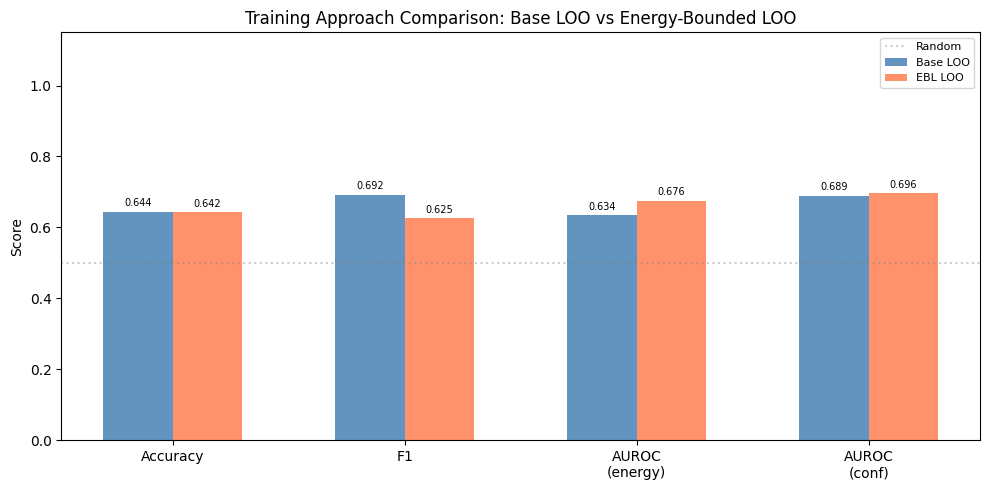

Saved: training_comparison.png


In [ ]:
import matplotlib.pyplot as plt

print("=" * 90)
print("COMPARISON: Training Approaches")
print("=" * 90)
print(f"{'Metric':<25} {'Base LOO':>12} {'EBL LOO':>12}")
print("-" * 55)

comparisons = [
    ("Accuracy",           base_global_acc,    loo_ebl_global_acc),
    ("F1",                 base_global_f1,     loo_ebl_global_f1),
    ("AUROC (energy)",     base_auroc_energy,  loo_ebl_auroc_energy),
    ("AUROC (confidence)", base_auroc_conf,    loo_ebl_auroc_conf),
    ("FPR@95TPR (energy)", base_fpr_energy,    loo_ebl_fpr_energy),
    ("FPR@95TPR (conf)",   base_fpr_conf,      loo_ebl_fpr_conf),
]

for name, v1, v2 in comparisons:
    vals = [v1, v2]
    if "FPR" in name:
        best_idx = vals.index(min(vals))
    else:
        best_idx = vals.index(max(vals))
    markers = ["", ""]
    markers[best_idx] = " ◄"
    print(f"{name:<25} {v1:>12.4f}{markers[0]:2s} {v2:>12.4f}{markers[1]:2s}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
metrics_names = ["Accuracy", "F1", "AUROC\n(energy)", "AUROC\n(conf)"]
base_vals = [base_global_acc, base_global_f1, base_auroc_energy, base_auroc_conf]
ebl_vals = [loo_ebl_global_acc, loo_ebl_global_f1, loo_ebl_auroc_energy, loo_ebl_auroc_conf]

x = np.arange(len(metrics_names))
width = 0.3
b1 = ax.bar(x - width/2, base_vals, width, label="Base LOO", color="steelblue", alpha=0.85)
b2 = ax.bar(x + width/2, ebl_vals, width, label="EBL LOO", color="coral", alpha=0.85)

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylabel("Score")
ax.set_title("Training Approach Comparison: Base LOO vs Energy-Bounded LOO")
ax.set_ylim(0, 1.15)
ax.axhline(y=0.5, color="gray", linestyle=":", alpha=0.4, label="Random")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("training_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_comparison.png")

## Confusion Matrix Visualization

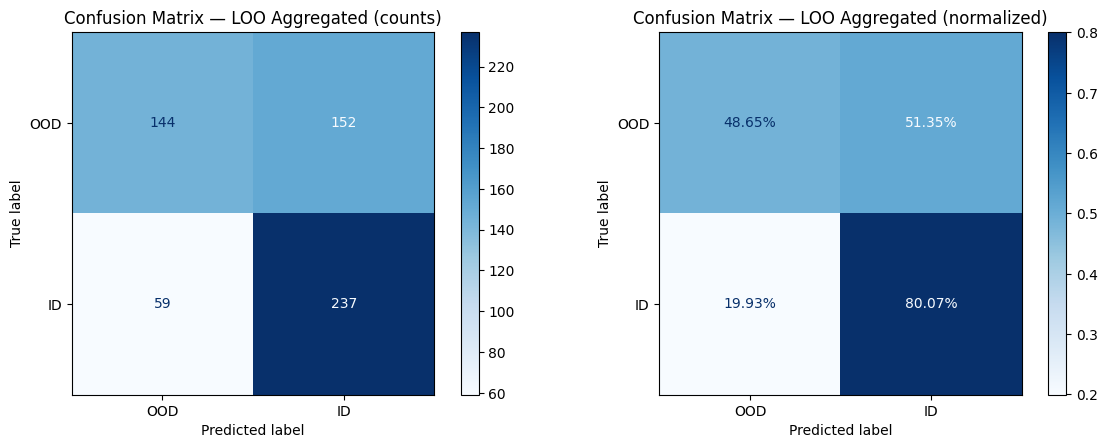

True Negatives (correct OOD):  144
False Positives (ID as OOD):   152
False Negatives (OOD as ID):   59
True Positives (correct ID):   237
Precision: 0.6093
Recall:    0.8007
Saved: confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(global_labels, global_preds)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

disp1 = ConfusionMatrixDisplay(cm, display_labels=["OOD", "ID"])
disp1.plot(ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title("Confusion Matrix — LOO Aggregated (counts)")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(cm_norm, display_labels=["OOD", "ID"])
disp2.plot(ax=axes[1], cmap="Blues", values_format=".2%")
axes[1].set_title("Confusion Matrix — LOO Aggregated (normalized)")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correct OOD):  {tn}")
print(f"False Positives (ID as OOD):   {fp}")
print(f"False Negatives (OOD as ID):   {fn}")
print(f"True Positives (correct ID):   {tp}")
print(f"Precision: {tp/(tp+fp):.4f}")
print(f"Recall:    {tp/(tp+fn):.4f}")
print(f"Saved: confusion_matrix.png")

## Cell 11: Training Curves

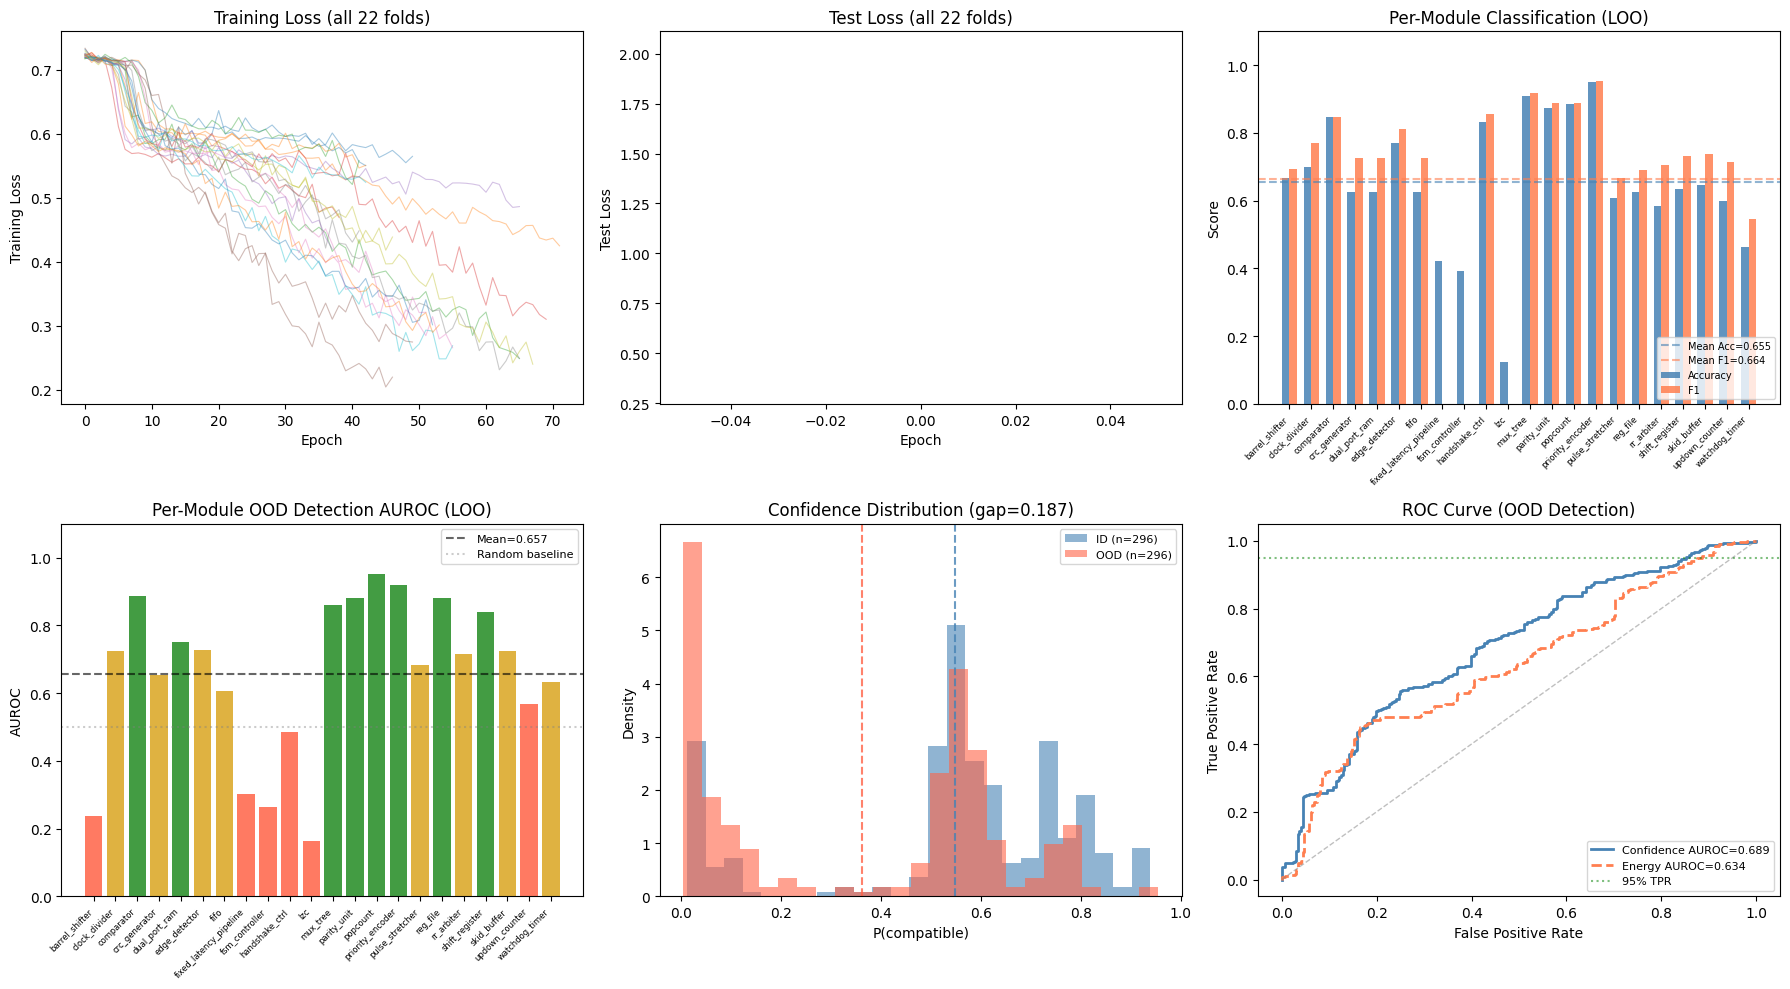

Saved: loo_results.png

Aggregated LOO Results (22 modules):
  Accuracy:           0.6550 +/- 0.1896
  F1:                 0.6636 +/- 0.2793
  AUROC (confidence): 0.6889
  AUROC (energy):     0.6335
  Confidence gap:     0.1868


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve as sk_roc_curve, roc_auc_score

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Training loss curves (all folds overlaid)
for mod, hist in all_histories.items():
    axes[0, 0].plot(hist["train_loss"], alpha=0.4, linewidth=0.8)
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Training Loss")
axes[0, 0].set_title(f"Training Loss (all {len(all_histories)} folds)")

# Plot 2: Test loss curves (all folds overlaid)
for mod, hist in all_histories.items():
    axes[0, 1].plot(hist["test_loss"], alpha=0.4, linewidth=0.8)
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Test Loss")
axes[0, 1].set_title(f"Test Loss (all {len(all_histories)} folds)")

# Plot 3: Per-module Accuracy & F1
fold_names = list(all_loo_results.keys())
fold_accs = [all_loo_results[m].classification_accuracy for m in fold_names]
fold_f1s = [all_loo_results[m].f1 for m in fold_names]
fold_aurocs = [all_loo_results[m].auroc for m in fold_names]

x = np.arange(len(fold_names))
width = 0.35
axes[0, 2].bar(x - width/2, fold_accs, width, label="Accuracy", color="steelblue", alpha=0.85)
axes[0, 2].bar(x + width/2, fold_f1s, width, label="F1", color="coral", alpha=0.85)
axes[0, 2].axhline(y=np.mean(fold_accs), color="steelblue", linestyle="--", alpha=0.6,
                    label=f"Mean Acc={np.mean(fold_accs):.3f}")
axes[0, 2].axhline(y=np.mean(fold_f1s), color="coral", linestyle="--", alpha=0.6,
                    label=f"Mean F1={np.mean(fold_f1s):.3f}")
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(fold_names, rotation=45, ha="right", fontsize=6)
axes[0, 2].set_ylabel("Score")
axes[0, 2].set_title("Per-Module Classification (LOO)")
axes[0, 2].set_ylim(0, 1.1)
axes[0, 2].legend(fontsize=7, loc="lower right")

# Plot 4: Per-module AUROC
colors = ["forestgreen" if a >= 0.75 else "goldenrod" if a >= 0.6 else "tomato" for a in fold_aurocs]
axes[1, 0].bar(x, fold_aurocs, color=colors, alpha=0.85)
axes[1, 0].axhline(y=np.mean(fold_aurocs), color="black", linestyle="--", alpha=0.6,
                    label=f"Mean={np.mean(fold_aurocs):.3f}")
axes[1, 0].axhline(y=0.5, color="gray", linestyle=":", alpha=0.4, label="Random baseline")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(fold_names, rotation=45, ha="right", fontsize=6)
axes[1, 0].set_ylabel("AUROC")
axes[1, 0].set_title("Per-Module OOD Detection AUROC (LOO)")
axes[1, 0].set_ylim(0, 1.1)
axes[1, 0].legend(fontsize=8)

# Plot 5: Confidence Distribution
id_conf = global_confidence[global_labels == 1]
ood_conf = global_confidence[global_labels == 0]
axes[1, 1].hist(id_conf, bins=25, alpha=0.6, label=f"ID (n={len(id_conf)})", color="steelblue", density=True)
axes[1, 1].hist(ood_conf, bins=25, alpha=0.6, label=f"OOD (n={len(ood_conf)})", color="tomato", density=True)
axes[1, 1].axvline(x=id_conf.mean(), color="steelblue", linestyle="--", alpha=0.8)
axes[1, 1].axvline(x=ood_conf.mean(), color="tomato", linestyle="--", alpha=0.8)
axes[1, 1].set_xlabel("P(compatible)")
axes[1, 1].set_ylabel("Density")
axes[1, 1].set_title(f"Confidence Distribution (gap={id_conf.mean()-ood_conf.mean():.3f})")
axes[1, 1].legend(fontsize=8)

# Plot 6: ROC Curve
ood_labels_global = 1 - global_labels

fpr_c, tpr_c, _ = sk_roc_curve(ood_labels_global, -global_confidence)
auroc_c = roc_auc_score(ood_labels_global, -global_confidence)
if auroc_c < 0.5:
    fpr_c, tpr_c, _ = sk_roc_curve(ood_labels_global, global_confidence)
    auroc_c = 1 - auroc_c

fpr_e, tpr_e, _ = sk_roc_curve(ood_labels_global, global_energy)
auroc_e = roc_auc_score(ood_labels_global, global_energy)
if auroc_e < 0.5:
    fpr_e, tpr_e, _ = sk_roc_curve(ood_labels_global, -global_energy)
    auroc_e = 1 - auroc_e

axes[1, 2].plot(fpr_c, tpr_c, color="steelblue", lw=2, label=f"Confidence AUROC={auroc_c:.3f}")
axes[1, 2].plot(fpr_e, tpr_e, color="coral", lw=2, linestyle="--", label=f"Energy AUROC={auroc_e:.3f}")
axes[1, 2].plot([0, 1], [0, 1], "--", color="gray", lw=1, alpha=0.5)
axes[1, 2].axhline(y=0.95, color="green", linestyle=":", alpha=0.5, label="95% TPR")
axes[1, 2].set_xlabel("False Positive Rate")
axes[1, 2].set_ylabel("True Positive Rate")
axes[1, 2].set_title("ROC Curve (OOD Detection)")
axes[1, 2].legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("loo_results.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: loo_results.png")
print(f"\nAggregated LOO Results ({len(fold_names)} modules):")
print(f"  Accuracy:           {np.mean(fold_accs):.4f} +/- {np.std(fold_accs):.4f}")
print(f"  F1:                 {np.mean(fold_f1s):.4f} +/- {np.std(fold_f1s):.4f}")
print(f"  AUROC (confidence): {auroc_conf:.4f}")
print(f"  AUROC (energy):     {auroc_energy:.4f}")
print(f"  Confidence gap:     {id_conf.mean() - ood_conf.mean():.4f}")

## Cell 13: Energy Score Distribution & ROC Curve

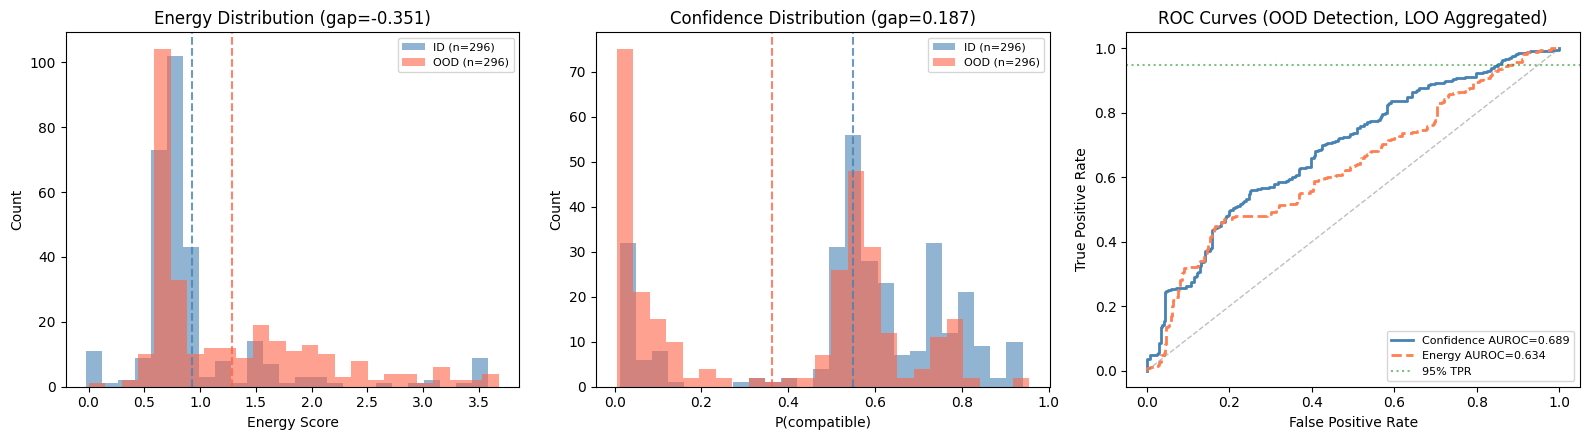

Saved: ood_analysis.png

Aggregated across 22 LOO folds:
  Samples:              592 (296 ID, 296 OOD)
  Classification Acc:   0.6436
  AUROC (confidence):   0.6889
  AUROC (energy):       0.6335


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve as sk_roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Energy Distribution
id_energy = global_energy[global_labels == 1]
ood_energy = global_energy[global_labels == 0]
axes[0].hist(id_energy, bins=25, alpha=0.6, label=f"ID (n={len(id_energy)})", color="steelblue")
axes[0].hist(ood_energy, bins=25, alpha=0.6, label=f"OOD (n={len(ood_energy)})", color="tomato")
axes[0].axvline(x=id_energy.mean(), color="steelblue", linestyle="--", alpha=0.8)
axes[0].axvline(x=ood_energy.mean(), color="tomato", linestyle="--", alpha=0.8)
axes[0].set_xlabel("Energy Score")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Energy Distribution (gap={id_energy.mean()-ood_energy.mean():.3f})")
axes[0].legend(fontsize=8)

# Confidence Distribution
id_conf = global_confidence[global_labels == 1]
ood_conf = global_confidence[global_labels == 0]
axes[1].hist(id_conf, bins=25, alpha=0.6, label=f"ID (n={len(id_conf)})", color="steelblue")
axes[1].hist(ood_conf, bins=25, alpha=0.6, label=f"OOD (n={len(ood_conf)})", color="tomato")
axes[1].axvline(x=id_conf.mean(), color="steelblue", linestyle="--", alpha=0.8)
axes[1].axvline(x=ood_conf.mean(), color="tomato", linestyle="--", alpha=0.8)
axes[1].set_xlabel("P(compatible)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Confidence Distribution (gap={id_conf.mean()-ood_conf.mean():.3f})")
axes[1].legend(fontsize=8)

# ROC Curves (both methods)
ood_labels_global = 1 - global_labels

# Confidence ROC
fpr_c, tpr_c, _ = sk_roc_curve(ood_labels_global, -global_confidence)
a_c = roc_auc_score(ood_labels_global, -global_confidence)
if a_c < 0.5:
    fpr_c, tpr_c, _ = sk_roc_curve(ood_labels_global, global_confidence)
    a_c = 1 - a_c

# Energy ROC
fpr_e, tpr_e, _ = sk_roc_curve(ood_labels_global, global_energy)
a_e = roc_auc_score(ood_labels_global, global_energy)
if a_e < 0.5:
    fpr_e, tpr_e, _ = sk_roc_curve(ood_labels_global, -global_energy)
    a_e = 1 - a_e

axes[2].plot(fpr_c, tpr_c, color="steelblue", lw=2, label=f"Confidence AUROC={a_c:.3f}")
axes[2].plot(fpr_e, tpr_e, color="coral", lw=2, linestyle="--", label=f"Energy AUROC={a_e:.3f}")
axes[2].plot([0, 1], [0, 1], "--", color="gray", lw=1, alpha=0.5)
axes[2].axhline(y=0.95, color="green", linestyle=":", alpha=0.5, label="95% TPR")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC Curves (OOD Detection, LOO Aggregated)")
axes[2].legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("ood_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: ood_analysis.png")
print(f"\nAggregated across {len(all_loo_results)} LOO folds:")
print(f"  Samples:              {len(global_labels)} ({int(global_labels.sum())} ID, {int((1-global_labels).sum())} OOD)")
print(f"  Classification Acc:   {(global_labels == global_preds).mean():.4f}")
print(f"  AUROC (confidence):   {a_c:.4f}")
print(f"  AUROC (energy):       {a_e:.4f}")

## Cell 14: Ablation Test - Definition Anonymized vs Original Identifiers


In [ ]:
def run_ablation_experiment(anonymize_flag, modules_dict, rtl_features_dict, seed=42):
    """
    Run full preprocess -> train -> evaluate with given anonymization setting,
    matching the current main LOO training setup as closely as possible.
    """
    from sklearn.preprocessing import StandardScaler
    import random

    RTL_HIDDEN_DIM = 64
    EMBEDDING_DIM = 32
    LSTM_HIDDEN_DIM = 64
    LSTM_NUM_LAYERS = 1
    LSTM_DROPOUT = 0.2
    JOINT_HIDDEN_DIM = 128
    NUM_CLASSES = 2
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-3
    EPOCHS = 300
    PATIENCE = 30
    TEMPERATURE = 1.0
    CONTRASTIVE_WEIGHT = 0.05    # weight for cosine embedding loss
    CONTRASTIVE_MARGIN = 0.2

    # Build SVA text with or without anonymization
    sva_data = {}
    for name, (rtl_path, sva_path) in modules_dict.items():
        raw_props = parse_sva_file(sva_path)

        if anonymize_flag:
            am = AnonymizationMap()
            rtl_text = rtl_path.read_text()
            _, am = anonymize_rtl(rtl_text, preserve_port_roles=True, anon_map=am)
            sva_data[name] = [anonymize_sva(p, am) for p in raw_props]
        else:
            sva_data[name] = raw_props

    # Tokenize exactly like main pipeline
    all_texts = [p for props in sva_data.values() for p in props]
    tok = SVATokenizer(max_seq_len=MAX_SEQ_LEN)
    tok.build_vocab(all_texts)

    seqs, lens = {}, {}
    for name, props in sva_data.items():
        seq_list, len_list = [], []
        for p in props:
            tokens = tok.tokenize(p)
            seq_list.append(tok.encode(p))
            len_list.append(min(len(tokens) + 2, MAX_SEQ_LEN))
        seqs[name] = seq_list
        lens[name] = len_list

    # Build RAW RTL feature vectors (per-fold scaling comes later)
    raw_feat_vecs = {}
    for name in modules_dict:
        if name not in rtl_features_dict:
            continue

        feat_obj = rtl_features_dict[name]

        if hasattr(feat_obj, "to_vector"):
            raw_feat_vecs[name] = feat_obj.to_vector().astype(np.float32)
        else:
            raw_feat_vecs[name] = np.array(feat_obj, dtype=np.float32)

    module_names = sorted(raw_feat_vecs.keys())

    all_labels = []
    all_preds = []
    all_energy = []
    all_conf = []

    criterion_local = nn.CrossEntropyLoss(label_smoothing=0.05)
    contrastive_local = nn.CosineEmbeddingLoss(margin=CONTRASTIVE_MARGIN)

    # Leave-one-out CV
    for fold, held_out in enumerate(module_names):
        torch.manual_seed(seed)
        np.random.seed(seed)

        # Per-fold scaling on training modules only
        train_modules_for_scaler = [m for m in module_names if m != held_out]

        scaler = StandardScaler()
        train_matrix = np.stack([raw_feat_vecs[m] for m in train_modules_for_scaler])
        scaler.fit(train_matrix)

        feat_vecs_fold = {}
        for m in module_names:
            feat_vecs_fold[m] = scaler.transform(
                raw_feat_vecs[m].reshape(1, -1)
            )[0].astype(np.float32)

        # Build datasets
        train_ds_full, test_ds = leave_one_out_split(
            feat_vecs_fold,
            seqs,
            lens,
            held_out_module=held_out,
            ood_ratio=1.0,
            seed=seed,
        )

        # Internal validation split for early stopping
        n_val_inner = max(2, int(0.15 * len(train_ds_full)))
        n_train_inner = len(train_ds_full) - n_val_inner

        train_ds, val_ds_inner = random_split(
            train_ds_full,
            [n_train_inner, n_val_inner],
            generator=torch.Generator().manual_seed(seed + fold)
        )

        tr_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_ds_inner, batch_size=BATCH_SIZE, shuffle=False)
        te_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

        # Model
        mdl = CompatibilityClassifier(
            vocab_size=tok.vocab_size,
            rtl_feature_dim=len(next(iter(feat_vecs_fold.values()))),
            rtl_hidden_dim=RTL_HIDDEN_DIM,
            embedding_dim=EMBEDDING_DIM,
            lstm_hidden_dim=LSTM_HIDDEN_DIM,
            lstm_num_layers=LSTM_NUM_LAYERS,
            lstm_dropout=LSTM_DROPOUT,
            joint_hidden_dim=JOINT_HIDDEN_DIM,
            num_classes=NUM_CLASSES,
            pad_idx=tok.pad_idx,
        ).to(device)

        opt = torch.optim.AdamW(
            mdl.parameters(),
            lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY
        )

        best_val_loss = float("inf")
        patience_ctr = 0
        best_state = None

        # Train with CE + contrastive, early stop on CE only
        for ep in range(1, EPOCHS + 1):
            mdl.train()

            for batch in tr_loader:
                rtl_feat = batch["rtl_features"].to(device)
                sva_ids = batch["sva_input_ids"].to(device)
                sva_len = batch["sva_length"].to(device)
                labels = batch["label"].to(device)

                opt.zero_grad()

                logits = mdl(rtl_feat, sva_ids, sva_len)
                ce_loss = criterion_local(logits, labels)

                rtl_emb, sva_emb = mdl.encode_pair(rtl_feat, sva_ids, sva_len)
                contrastive_target = labels.float() * 2 - 1
                metric_loss = contrastive_local(rtl_emb, sva_emb, contrastive_target)

                loss = ce_loss + CONTRASTIVE_WEIGHT * metric_loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
                opt.step()

            # Validation: CE only, matching your current main setup
            mdl.eval()
            val_loss = 0.0
            val_batches = 0

            with torch.no_grad():
                for batch in val_loader:
                    logits = mdl(
                        batch["rtl_features"].to(device),
                        batch["sva_input_ids"].to(device),
                        batch["sva_length"].to(device),
                    )
                    val_loss += criterion_local(logits, batch["label"].to(device)).item()
                    val_batches += 1

            val_loss /= max(val_batches, 1)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_ctr = 0
                best_state = {k: v.detach().cpu().clone() for k, v in mdl.state_dict().items()}
            else:
                patience_ctr += 1

            if patience_ctr >= PATIENCE:
                break


        # Evaluate best model on held-out fold
        if best_state is None:
            best_state = {k: v.detach().cpu().clone() for k, v in mdl.state_dict().items()}

        mdl.load_state_dict(best_state)
        mdl.eval()

        with torch.no_grad():
            for batch in te_loader:
                logits = mdl(
                    batch["rtl_features"].to(device),
                    batch["sva_input_ids"].to(device),
                    batch["sva_length"].to(device),
                )
                probs = torch.softmax(logits, dim=1)

                all_labels.append(batch["label"].cpu().numpy())
                all_preds.append(logits.argmax(1).cpu().numpy())

                # Match your CURRENT energy convention:
                # compute_auroc expects higher score = more OOD
                # and your current chosen convention is NEGATED energy
                all_energy.append((-energy_score(logits, TEMPERATURE)).cpu().numpy())  # negated: higher = more OOD

                # probs[:,1] = P(ID), so will negate later for OOD AUROC
                all_conf.append(probs[:, 1].cpu().numpy())

    # Aggregate results across all folds
    labels = np.concatenate(all_labels)
    preds = np.concatenate(all_preds)
    energy = np.concatenate(all_energy)
    conf = np.concatenate(all_conf)

    acc = (labels == preds).mean()
    f1_val = f1_score(labels, preds, zero_division=0)

    auroc_c = compute_auroc(labels, -conf)     # higher = more OOD
    auroc_e = compute_auroc(labels, energy)    # already negated above
    fpr_c = compute_fpr_at_95tpr(labels, -conf)
    fpr_e = compute_fpr_at_95tpr(labels, energy)

    return {
        "accuracy": acc,
        "f1": f1_val,
        "auroc_confidence": auroc_c,
        "auroc_energy": auroc_e,
        "fpr95_confidence": fpr_c,
        "fpr95_energy": fpr_e,
    }

## Cell 14b: Ablation Test

In [ ]:
print("Running ablation: Anonymized identifiers (LOO)...")
m_anon = run_ablation_experiment(True, modules, rtl_features)
print(
    f"  Acc={m_anon['accuracy']:.4f} "
    f"F1={m_anon['f1']:.4f} "
    f"AUROC(conf)={m_anon['auroc_confidence']:.4f} "
    f"AUROC(energy)={m_anon['auroc_energy']:.4f} "
    f"FPR95(conf)={m_anon['fpr95_confidence']:.4f} "
    f"FPR95(energy)={m_anon['fpr95_energy']:.4f}\n"
)

print("Running ablation: Original identifiers (LOO)...")
m_orig = run_ablation_experiment(False, modules, rtl_features)
print(
    f"  Acc={m_orig['accuracy']:.4f} "
    f"F1={m_orig['f1']:.4f} "
    f"AUROC(conf)={m_orig['auroc_confidence']:.4f} "
    f"AUROC(energy)={m_orig['auroc_energy']:.4f} "
    f"FPR95(conf)={m_orig['fpr95_confidence']:.4f} "
    f"FPR95(energy)={m_orig['fpr95_energy']:.4f}\n"
)

print("=" * 90)
print("ABLATION: Identifier Anonymization (LOO Aggregated)")
print("=" * 90)
print(f"{'Metric':<25} {'Anonymized':>12} {'Original':>12} {'Delta':>12}")
print("-" * 65)

for attr in [
    "accuracy",
    "f1",
    "auroc_confidence",
    "auroc_energy",
    "fpr95_confidence",
    "fpr95_energy",
]:
    va = m_anon[attr]
    vo = m_orig[attr]
    d = va - vo
    print(f"{attr:<25} {va:>12.4f} {vo:>12.4f} {d:>+12.4f}")

print("\nInterpretation:")
acc_diff = m_anon["accuracy"] - m_orig["accuracy"]

if acc_diff > 0.02:
    print("  Anonymization improves performance — the model was partially relying")
    print("  on identifier names. Anonymization forces more structural learning.")
elif acc_diff < -0.02:
    print("  Original identifiers perform better — signal names may carry useful")
    print("  semantic information that helps compatibility detection.")
else:
    print("  Similar performance — the model is not strongly dependent on identifier")
    print("  names under the current training setup.")

Running ablation: Anonymized identifiers (LOO)...
  Acc=0.6622 F1=0.6988 AUROC(conf)=0.7202 AUROC(energy)=0.6558 FPR95(conf)=0.8784 FPR95(energy)=0.8412

Running ablation: Original identifiers (LOO)...
  Acc=0.6622 F1=0.6491 AUROC(conf)=0.7254 AUROC(energy)=0.6233 FPR95(conf)=0.8682 FPR95(energy)=0.9257

ABLATION: Identifier Anonymization (LOO Aggregated)
Metric                      Anonymized     Original        Delta
-----------------------------------------------------------------
accuracy                        0.6622       0.6622      +0.0000
f1                              0.6988       0.6491      +0.0497
auroc_confidence                0.7202       0.7254      -0.0053
auroc_energy                    0.6558       0.6233      +0.0325
fpr95_confidence                0.8784       0.8682      +0.0101
fpr95_energy                    0.8412       0.9257      -0.0845

Interpretation:
  Similar performance — the model is not strongly dependent on identifier
  names under the current trai

## Cell 15: Anonymization Ablation Visualization

In [ ]:
import matplotlib.pyplot as plt

metrics_list = ["accuracy", "f1", "auroc_confidence", "auroc_energy"]
labels = ["Accuracy", "F1", "AUROC\n(confidence)", "AUROC\n(energy)"]
anon_vals = [m_anon[m] for m in metrics_list]
orig_vals = [m_orig[m] for m in metrics_list]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(labels))
width = 0.3

bars1 = ax.bar(x - width/2, anon_vals, width, label="Anonymized", color="steelblue", alpha=0.85)
bars2 = ax.bar(x + width/2, orig_vals, width, label="Original", color="coral", alpha=0.85)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Score")
ax.set_title("Ablation: Anonymized vs Original Identifiers")
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color="gray", linestyle=":", alpha=0.4, label="Random baseline")
ax.legend()

plt.tight_layout()
plt.savefig("ablation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ablation_comparison.png")

## Cell 16: Architecture Ablation: RTL-only vs SVA-only vs Joint

Running architecture ablation...

1/3: Joint model (RTL + SVA)...
    Acc=0.7466  F1=0.7706  AUROC=0.8269

2/3: RTL-only (SVA zeroed out)...
    Acc=0.5000  F1=0.0864  AUROC=0.5028

3/3: SVA-only (RTL zeroed out)...
    Acc=0.5270  F1=0.2929  AUROC=0.5451

ARCHITECTURE ABLATION
Model                  Accuracy         F1      AUROC
--------------------------------------------------
Joint (full)             0.7466     0.7706     0.8269
RTL-only                 0.5000     0.0864     0.5028
SVA-only                 0.5270     0.2929     0.5451


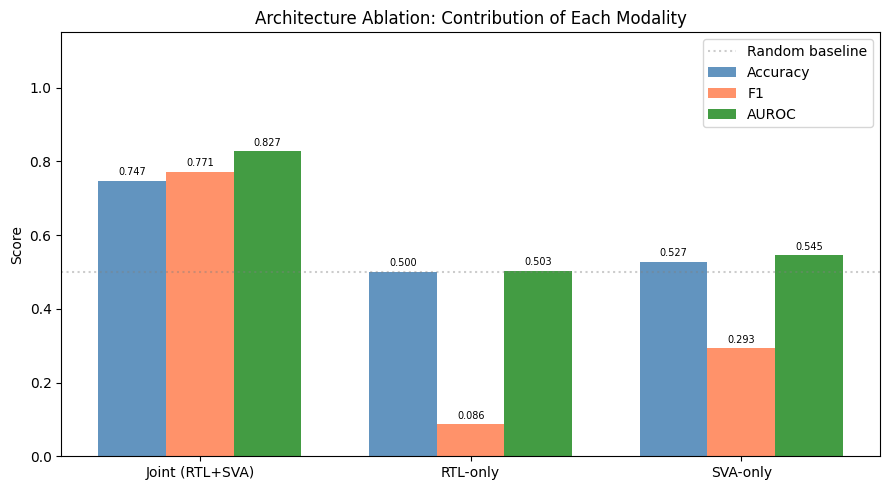

Saved: architecture_ablation.png


In [ ]:
import warnings
warnings.filterwarnings('ignore')

def run_architecture_ablation(mode="joint"):
    """mode: 'rtl_only', 'sva_only', or 'joint'"""

    RTL_HIDDEN_DIM = 64
    EMBEDDING_DIM = 32
    LSTM_HIDDEN_DIM = 64
    LSTM_NUM_LAYERS = 1
    LSTM_DROPOUT = 0.2
    JOINT_HIDDEN_DIM = 128
    NUM_CLASSES = 2
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-3
    EPOCHS = 300
    PATIENCE = 30
    TEMPERATURE = 1.0
    CONTRASTIVE_WEIGHT = 0.05    # weight for cosine embedding loss
    CONTRASTIVE_MARGIN = 0.2
    all_labels, all_preds, all_conf = [], [], []

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    contrastive_criterion = nn.CosineEmbeddingLoss(margin=CONTRASTIVE_MARGIN)

    for held_out in sorted(rtl_feature_vectors.keys()):
        torch.manual_seed(SEED)
        train_ds, test_ds = leave_one_out_split(
            rtl_feature_vectors, sva_sequences, sva_lengths,
            held_out_module=held_out, ood_ratio=1.0, seed=SEED,
        )
        tr_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        te_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

        mdl = CompatibilityClassifier(
            vocab_size=tokenizer.vocab_size,
            rtl_feature_dim=RTL_FEATURE_DIM, rtl_hidden_dim=RTL_HIDDEN_DIM,
            embedding_dim=EMBEDDING_DIM, lstm_hidden_dim=LSTM_HIDDEN_DIM,
            lstm_num_layers=LSTM_NUM_LAYERS, lstm_dropout=LSTM_DROPOUT,
            joint_hidden_dim=JOINT_HIDDEN_DIM, num_classes=NUM_CLASSES,
            pad_idx=tokenizer.pad_idx,
        ).to(device)
        opt = torch.optim.Adam(mdl.parameters(), lr=LEARNING_RATE)

        best_loss, patience_ctr, best_state = float("inf"), 0, None
        for ep in range(EPOCHS):
            mdl.train()
            for batch in tr_loader:
                opt.zero_grad()
                rtl_feat = batch["rtl_features"].to(device)
                sva_ids = batch["sva_input_ids"].to(device)
                sva_len = batch["sva_length"].to(device)
                if mode == "rtl_only":
                    sva_ids = torch.zeros_like(sva_ids)
                elif mode == "sva_only":
                    rtl_feat = torch.zeros_like(rtl_feat)
                logits = mdl(rtl_feat, sva_ids, sva_len)
                loss = criterion(logits, batch["label"].to(device))
                loss.backward()
                torch.nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
                opt.step()

            mdl.eval()
            te_loss = 0
            with torch.no_grad():
                for batch in te_loader:
                    rtl_feat = batch["rtl_features"].to(device)
                    sva_ids = batch["sva_input_ids"].to(device)
                    sva_len = batch["sva_length"].to(device)
                    if mode == "rtl_only":
                        sva_ids = torch.zeros_like(sva_ids)
                    elif mode == "sva_only":
                        rtl_feat = torch.zeros_like(rtl_feat)
                    logits = mdl(rtl_feat, sva_ids, sva_len)
                    te_loss += criterion(logits, batch["label"].to(device)).item()
            if te_loss < best_loss:
                best_loss = te_loss
                patience_ctr = 0
                best_state = {k: v.clone() for k, v in mdl.state_dict().items()}
            else:
                patience_ctr += 1
            if patience_ctr >= PATIENCE:
                break

        mdl.load_state_dict(best_state)
        mdl.eval()
        with torch.no_grad():
            for batch in te_loader:
                rtl_feat = batch["rtl_features"].to(device)
                sva_ids = batch["sva_input_ids"].to(device)
                sva_len = batch["sva_length"].to(device)
                if mode == "rtl_only":
                    sva_ids = torch.zeros_like(sva_ids)
                elif mode == "sva_only":
                    rtl_feat = torch.zeros_like(rtl_feat)
                logits = mdl(rtl_feat, sva_ids, sva_len)
                probs = torch.softmax(logits, dim=1)
                all_labels.append(batch["label"].numpy())
                all_preds.append(logits.argmax(1).cpu().numpy())
                all_conf.append(probs[:, 1].cpu().numpy())

    labels = np.concatenate(all_labels)
    preds = np.concatenate(all_preds)
    conf = np.concatenate(all_conf)
    acc = (labels == preds).mean()
    f1_val = f1_score(labels, preds, zero_division=0)
    ood_lab = 1 - labels
    auroc = roc_auc_score(ood_lab, -conf)
    return {"accuracy": acc, "f1": f1_val, "auroc": auroc}

print("Running architecture ablation...\n")

print("1/3: Joint model (RTL + SVA)...")
r_joint = run_architecture_ablation("joint")
print(f"    Acc={r_joint['accuracy']:.4f}  F1={r_joint['f1']:.4f}  AUROC={r_joint['auroc']:.4f}\n")

print("2/3: RTL-only (SVA zeroed out)...")
r_rtl = run_architecture_ablation("rtl_only")
print(f"    Acc={r_rtl['accuracy']:.4f}  F1={r_rtl['f1']:.4f}  AUROC={r_rtl['auroc']:.4f}\n")

print("3/3: SVA-only (RTL zeroed out)...")
r_sva = run_architecture_ablation("sva_only")
print(f"    Acc={r_sva['accuracy']:.4f}  F1={r_sva['f1']:.4f}  AUROC={r_sva['auroc']:.4f}\n")

print("=" * 60)
print("ARCHITECTURE ABLATION")
print("=" * 60)
print(f"{'Model':<20} {'Accuracy':>10} {'F1':>10} {'AUROC':>10}")
print("-" * 50)
print(f"{'Joint (full)':<20} {r_joint['accuracy']:>10.4f} {r_joint['f1']:>10.4f} {r_joint['auroc']:>10.4f}")
print(f"{'RTL-only':<20} {r_rtl['accuracy']:>10.4f} {r_rtl['f1']:>10.4f} {r_rtl['auroc']:>10.4f}")
print(f"{'SVA-only':<20} {r_sva['accuracy']:>10.4f} {r_sva['f1']:>10.4f} {r_sva['auroc']:>10.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(3)
width = 0.25
b1 = ax.bar(x - width, [r_joint['accuracy'], r_rtl['accuracy'], r_sva['accuracy']],
            width, label="Accuracy", color="steelblue", alpha=0.85)
b2 = ax.bar(x, [r_joint['f1'], r_rtl['f1'], r_sva['f1']],
            width, label="F1", color="coral", alpha=0.85)
b3 = ax.bar(x + width, [r_joint['auroc'], r_rtl['auroc'], r_sva['auroc']],
            width, label="AUROC", color="forestgreen", alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(["Joint (RTL+SVA)", "RTL-only", "SVA-only"])
ax.set_ylabel("Score")
ax.set_title("Architecture Ablation: Contribution of Each Modality")
ax.set_ylim(0, 1.15)
ax.axhline(y=0.5, color="gray", linestyle=":", alpha=0.4, label="Random baseline")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("architecture_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: architecture_ablation.png")

## Cell 17: Error Analysis: What makes modules easy vs hard?

ERROR ANALYSIS

5 HARDEST modules (lowest LOO accuracy):
  lzc                        Acc=0.125  AUROC=0.164  F1=0.000
  fsm_controller             Acc=0.393  AUROC=0.265  F1=0.000
  fixed_latency_pipeline     Acc=0.423  AUROC=0.302  F1=0.000
  watchdog_timer             Acc=0.464  AUROC=0.633  F1=0.545
  rr_arbiter                 Acc=0.583  AUROC=0.715  F1=0.706

5 EASIEST modules (highest LOO accuracy):
  comparator                 Acc=0.846  AUROC=0.888  F1=0.846
  parity_unit                Acc=0.875  AUROC=0.882  F1=0.889
  popcount                   Acc=0.885  AUROC=0.953  F1=0.889
  mux_tree                   Acc=0.909  AUROC=0.860  F1=0.917
  priority_encoder           Acc=0.950  AUROC=0.920  F1=0.952

STRUCTURAL NEIGHBORS (nearest module by feature distance):
Module                    Nearest Neighbor          Distance   LOO Acc
----------------------------------------------------------------------
barrel_shifter            mux_tree                      3.25     0.667
clock_d

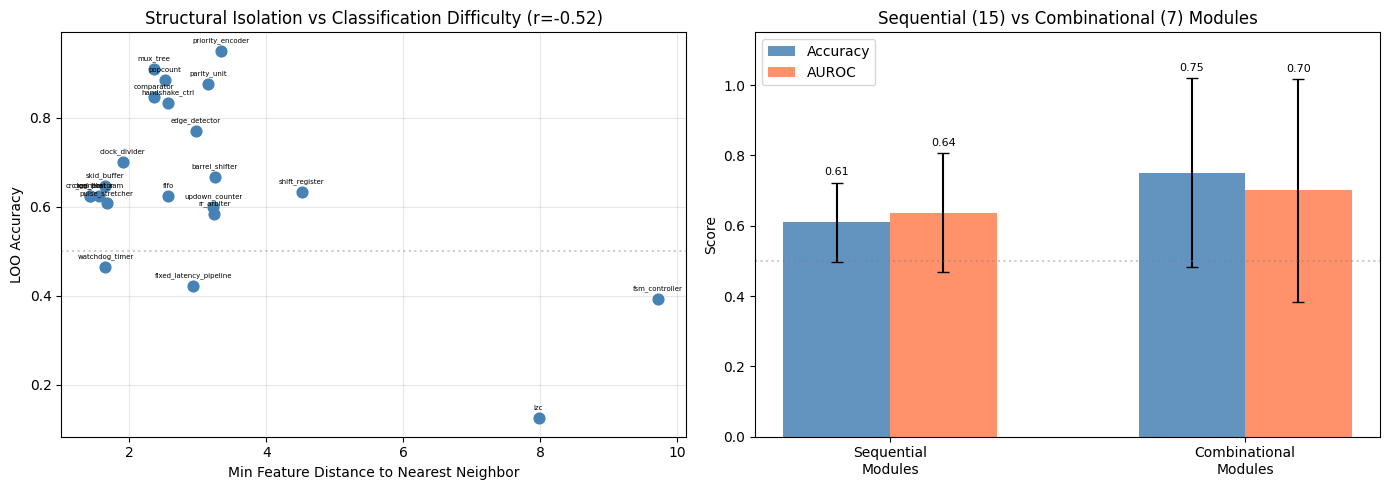

Saved: error_analysis.png


In [ ]:
# Sort by accuracy
sorted_results = sorted(all_loo_results.items(),
                        key=lambda x: x[1].classification_accuracy)

print("=" * 70)
print("ERROR ANALYSIS")
print("=" * 70)

print("\n5 HARDEST modules (lowest LOO accuracy):")
for name, m in sorted_results[:5]:
    print(f"  {name:25s}  Acc={m.classification_accuracy:.3f}  "
          f"AUROC={m.auroc:.3f}  F1={m.f1:.3f}")

print("\n5 EASIEST modules (highest LOO accuracy):")
for name, m in sorted_results[-5:]:
    print(f"  {name:25s}  Acc={m.classification_accuracy:.3f}  "
          f"AUROC={m.auroc:.3f}  F1={m.f1:.3f}")

# Structural similarity analysis
print("\nSTRUCTURAL NEIGHBORS (nearest module by feature distance):")
print(f"{'Module':<25} {'Nearest Neighbor':<25} {'Distance':>8}  {'LOO Acc':>8}")
print("-" * 70)
for name in sorted(rtl_feature_vectors.keys()):
    vec = rtl_feature_vectors[name]
    dists = [(other, np.linalg.norm(vec - rtl_feature_vectors[other]))
             for other in rtl_feature_vectors if other != name]
    dists.sort(key=lambda x: x[1])
    nearest, dist = dists[0]
    acc = all_loo_results[name].classification_accuracy
    marker = " ◄ hard" if acc < 0.65 else ""
    print(f"{name:<25} {nearest:<25} {dist:>8.2f}  {acc:>8.3f}{marker}")

# Correlation between feature distance and accuracy
all_min_dists = []
all_accs = []
for name in rtl_feature_vectors:
    vec = rtl_feature_vectors[name]
    min_dist = min(np.linalg.norm(vec - rtl_feature_vectors[o])
                   for o in rtl_feature_vectors if o != name)
    all_min_dists.append(min_dist)
    all_accs.append(all_loo_results[name].classification_accuracy)

corr = np.corrcoef(all_min_dists, all_accs)[0, 1]
print(f"\nCorrelation (min feature distance vs accuracy): {corr:.3f}")
if corr > 0.3:
    print("  → Modules that are structurally unique are easier to classify.")
    print("  → Hard modules have close structural neighbors.")
elif corr < -0.3:
    print("  → Unexpectedly, isolated modules are harder.")
else:
    print("  → Weak correlation — structural distance alone doesn't explain difficulty.")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy vs structural isolation
axes[0].scatter(all_min_dists, all_accs, c="steelblue", s=60, zorder=3)
for i, name in enumerate(rtl_feature_vectors.keys()):
    axes[0].annotate(name, (all_min_dists[i], all_accs[i]),
                     fontsize=5, ha="center", va="bottom",
                     textcoords="offset points", xytext=(0, 5))
axes[0].set_xlabel("Min Feature Distance to Nearest Neighbor")
axes[0].set_ylabel("LOO Accuracy")
axes[0].set_title(f"Structural Isolation vs Classification Difficulty (r={corr:.2f})")
axes[0].axhline(y=0.5, color="gray", linestyle=":", alpha=0.4)
axes[0].grid(alpha=0.3)

# Plot 2: Sequential vs Combinational performance
seq_accs = [all_loo_results[n].classification_accuracy
            for n in rtl_feature_vectors if rtl_features[n].has_clock]
comb_accs = [all_loo_results[n].classification_accuracy
             for n in rtl_feature_vectors if not rtl_features[n].has_clock]
seq_aurocs = [all_loo_results[n].auroc
              for n in rtl_feature_vectors if rtl_features[n].has_clock]
comb_aurocs = [all_loo_results[n].auroc
               for n in rtl_feature_vectors if not rtl_features[n].has_clock]

categories = ["Sequential\nModules", "Combinational\nModules"]
acc_means = [np.mean(seq_accs), np.mean(comb_accs)]
acc_stds = [np.std(seq_accs), np.std(comb_accs)]
auroc_means = [np.mean(seq_aurocs), np.mean(comb_aurocs)]
auroc_stds = [np.std(seq_aurocs), np.std(comb_aurocs)]

x = np.arange(2)
width = 0.3
axes[1].bar(x - width/2, acc_means, width, yerr=acc_stds,
            label="Accuracy", color="steelblue", alpha=0.85, capsize=4)
axes[1].bar(x + width/2, auroc_means, width, yerr=auroc_stds,
            label="AUROC", color="coral", alpha=0.85, capsize=4)
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel("Score")
axes[1].set_title(f"Sequential ({len(seq_accs)}) vs Combinational ({len(comb_accs)}) Modules")
axes[1].set_ylim(0, 1.15)
axes[1].axhline(y=0.5, color="gray", linestyle=":", alpha=0.4)
axes[1].legend()

# Add count labels
for i, (am, arm) in enumerate(zip(acc_means, auroc_means)):
    axes[1].text(i - width/2, am + acc_stds[i] + 0.02, f"{am:.2f}",
                 ha="center", fontsize=8)
    axes[1].text(i + width/2, arm + auroc_stds[i] + 0.02, f"{arm:.2f}",
                 ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: error_analysis.png")

## Cell 18: Download Results

In [ ]:
from google.colab import files
import os

os.makedirs("checkpoints", exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "vocab_size": tokenizer.vocab_size,
    "loo_results": {k: str(v) for k, v in all_loo_results.items()},
    "aggregated_metrics": {
        "accuracy": global_acc,
        "f1": global_f1,
        "auroc_confidence": auroc_conf,
        "auroc_energy": auroc_energy,
        "fpr95_confidence": fpr_conf,
        "fpr95_energy": fpr_energy,
    },
}, "checkpoints/final_model.pt")

print("Files available for download:")
expected_files = [
    "checkpoints/final_model.pt",
    "dataset_overview.png",
    "confusion_matrix.png",
    "loo_results.png",
    "ood_analysis.png",
    "ablation_comparison.png",
    "architecture_ablation.png",
    "error_analysis.png",
    "training_comparison.png",
]
for f in expected_files:
    status = "✓" if os.path.exists(f) else "✗ not found"
    print(f"  {f} — {status}")

for f in expected_files:
    if os.path.exists(f):
        files.download(f)

Files available for download:
  checkpoints/final_model.pt — ✓
  dataset_overview.png — ✓
  confusion_matrix.png — ✓
  loo_results.png — ✓
  ood_analysis.png — ✓
  ablation_comparison.png — ✓
  architecture_ablation.png — ✓
  error_analysis.png — ✓
  training_comparison.png — ✓


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>